# 8 · Design-Space and Pipeline Visualisation

**Author:** Héctor Fernández Pinacho  
**Lab:** IDEAL Lab · ETH Zürich

Visualises the propeller design space and every stage of the characterisation pipeline. Each section is self-contained: it loads its own CSV from `csv/` and is skipped gracefully when that file is absent. All figures are written as PNG into one tree, `plots/`, with one subfolder per pipeline stage (`plots/nb1/` … `plots/nb9/`): the per-stage diagnostic figures and the high-resolution (300 dpi) single-concept results figures used in the thesis, including the validation figures — which read the tables NB9 saves and are skipped gracefully until NB9 has run. This notebook also generates the two illustrative physics figures of the thesis (the representative low-Reynolds airfoil polar reconstructed from the pipeline's own QProp coefficient fit, and a single simulated free-flight trajectory integrated with exactly the NB6 equations of motion) and recomputes the spin-retention curve — the fraction of the target RPM the propeller still carries at the release instant, read directly from the raw launcher traces — writing `csv/06b_release_retention_curve_recomputed.csv` alongside its figure.

**Physics inputs:** all pipeline CSVs in `csv/` (NB1–NB7 outputs, the NB9 validation tables when present, and the cleaned launcher runs in `utils/results/*_cleaned/` for the retention curve)

**Physics outputs:** PNG figures in `plots/nb1/` … `plots/nb9/`, and `csv/06b_release_retention_curve_recomputed.csv` (the recomputed spin-retention evidence)

**Structure:**

1. Imports
2. Configuration — all tunable constants, paths and settings
3. Function definitions — shared plotting helpers and the high-resolution figure functions
4. Main code — configuration and one section per pipeline stage, followed by the high-resolution results figures


## 1. Imports

In [20]:
import os
import sys

os.environ['PYTHONDONTWRITEBYTECODE'] = '1'
sys.dont_write_bytecode = True

import glob
import math
import re
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import Normalize
from scipy.integrate import solve_ivp
from scipy.interpolate import CubicSpline

warnings.filterwarnings('ignore')

ROOT = Path('.')
if str(ROOT.resolve()) not in sys.path:
    sys.path.insert(0, str(ROOT.resolve()))
import pipeline_config as cfg
from utils import measurements

## 2. Configuration

In [21]:
CSV = ROOT / 'csv'
PLOTS = ROOT / 'plots'
PLOTS.mkdir(exist_ok=True)
HIRES_DPI = cfg.NB8_HIRES_DPI

plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.edgecolor': '#333333', 'axes.labelcolor': '#222222',
    'axes.titlecolor': '#111111', 'axes.titlesize': 11, 'axes.titleweight': 'bold',
    'axes.labelsize': 9, 'axes.grid': True, 'grid.color': '#DDDDDD', 'grid.linewidth': 0.6,
    'xtick.color': '#333333', 'ytick.color': '#333333',
    'text.color': '#111111', 'legend.frameon': True, 'legend.framealpha': 0.9,
    'figure.dpi': 120, 'savefig.dpi': 150, 'savefig.bbox': 'tight',
})

PALETTE = {'blue': '#4C72B0', 'orange': '#DD8452', 'green': '#55A868', 'red': '#C44E52',
           'purple': '#8172B3', 'brown': '#937860', 'teal': '#64B5CD', 'grey': '#8C8C8C',
           'gold': '#CCB974'}

CB = {
    'blue': '#0072B2',
    'orange': '#E69F00',
    'green': '#009E73',
    'red': '#D55E00',
    'purple': '#CC79A7',
    'sky': '#56B4E9',
    'yellow': '#F0E442',
    'black': '#000000',
    'grey': '#999999',
}

HIRES_STATIONS = ['hub', 's1', 's2', 's3', 's4', 's5', 's6']
HIRES_TIER_ORDER = ['viscous', 'viscous_near_re', 'hub_uses_s1', 'failed']
HIRES_TIER_COL = {'viscous': CB['green'], 'viscous_near_re': CB['sky'], 'hub_uses_s1': CB['orange'], 'failed': CB['red']}

INNER_ANCHOR_RADIUS_MM = cfg.INNER_ANCHOR_RADIUS_MM

LIFTOFF_HEIGHT_M = cfg.LIFTOFF_HEIGHT_M
HEIGHT_CEILING_M = cfg.HEIGHT_CEILING_M
KICK_VELOCITY_MS = cfg.KICK_VELOCITY_MS
H_KICK_FLOOR = KICK_VELOCITY_MS ** 2 / (2 * cfg.GRAVITY_M_S2)

RESULTS_DIR = measurements.results_dir(ROOT)
CLEANED_RUN_DIRS = measurements.cleaned_run_dirs(ROOT)
CLEAN_MAX_CLIMB_MS = cfg.RUN_MAX_CLIMB_SPEED_MS
RETENTION_LAUNCH_M = cfg.RETENTION_LAUNCH_M
PLATEAU_FRAC = cfg.PLATEAU_FRAC
JOINT_WINDOW_S = cfg.JOINT_WINDOW_S
RETENTION_MIN_CONF = cfg.RETENTION_MIN_CONF

print('Shared setup complete (light theme).')

Shared setup complete (light theme).


## 3. Function Definitions

**Shared helpers**

- **load(filename)** — loads one CSV from `csv/`, or prints a skip notice and returns None when it is absent.
- **savefig(name)** — saves the current figure into its `plots/nb<N>/` subfolder and shows it inline.
- **histplot(ax, data, color, title, xlabel, bins)** — histogram with a mean line, the standard panel of the diagnostic figures.
- **badge(label, n_pass, n_total, note)** — prints a PASS/WARN/FAIL line for a coverage check.
- **radial_profile(row, param, kind, n)** — spline-interpolates one blade parameter along the span exactly as NB1/NB3 do ('three' = natural cubic spline through inner/mid/outer, 'two' = linear inner/outer). Returns the normalised radius grid and the values.
- **plot_surface_box(cfg_sweep, value_col, zlabel, cmap, fname, title)** — 3-D operating surface (thrust or torque over V × RPM) for one config's sweep rows, saved to `plots/`.
- **save_png(fig, basename)** — saves a figure as a 300-dpi PNG into the given `plots/nb<N>/` subfolder and closes it.
- **need(path)** — returns the CSV path when present, else prints a skip notice and returns None.
- **header(title)** — section banner for the high-resolution figure log.

**High-resolution results figures** (one concept per file, 300-dpi PNG, saved into the `plots/nb<N>/` subfolder of the stage they document)

- **loft_three(row, param, rR) / loft_naca(row, param, rR)** — evaluate the pipeline's chord/twist (three-anchor) and thickness (two-anchor NACA) lofts on a normalised radius grid.
- **fig_gen_param_distributions()** — balance of the discrete and free sampled parameters (blade count, tip radius, pooled camber and max-camber position).
- **fig_gen_radial_evolution()** — the lofted radial evolution of chord, twist and thickness across the whole design space with the mean blade shape and anchor markers.
- **fig_selection_coverage()** — the 100 selected props overlaid on the 5000-design pool in two 2-D projections.
- **fig_aero_polar_tiers()** — stacked per-station polar-tier composition.
- **fig_aero_xfoil_convergence()** — usable-polar and exact-cache-hit shares versus Reynolds number, with the cached-Re grid marked.
- **fig_aero_confidence_hist()** — the thrust-weighted confidence score distribution with the admission threshold.
- **load_sweep_config(cid)** — streams the gzip sweep and returns the rows of one config.
- **surface_plot_hires(df, zcol, zlabel, title, basename)** — high-resolution 3-D operating surface.
- **fig_aero_qprop_surfaces(cid)** — thrust and torque surfaces of the reference propeller.
- **pick_polar_section(df, config, station, re_target)** — returns the ten fitted QProp polar coefficients of one (config, station), or auto-picks a viscous mid-station near the target Reynolds number.
- **qprop_polar(c, alpha_deg, re)** — evaluates exactly the polar model QProp queries downstream: the clipped linear lift curve, the asymmetric drag bucket, and the REexp Reynolds scaling.
- **fig_lowre_polar(config, station, re_target)** — the thesis background figure: lift curve and drag bucket of a real low-Reynolds mid-station section, with the laminar-separation-bubble regime annotated and the Reynolds sensitivity shown at half and double the reference Re.
- **build_trajectory_surface(sweep_df, cid) / interp_trajectory_surface(surface, v_query, omega_query) / make_trajectory_eom(mass, inertia, frontal_drag, surface) / trajectory_ground_hit(t, state)** — rebuild one config's T/Q surface and the NB6 equations of motion so the trajectory figure integrates exactly the pipeline's dynamics.
- **fig_release_trajectory(config)** — a single simulated free-flight trajectory: height, vertical speed and RPM on a shared time axis, with the peak annotated and the stored NB6 h_max cross-checked.

**Validation results figures** (read the tables NB9 saves; skipped with a notice until NB9 has run)

- **spearman_rho(a, b)** — Spearman rank correlation via NumPy rank correlation.
- **fig_val_mass_scatter() / inertia_stats(meas, pred) / fig_val_inertia_scatter()** — measured-vs-predicted mass and inertia scatters (raw and corrected) from `validation_mass_inertia.csv`.
- **load_matched_csv()** — loads `validation_sim_matched.csv`, the per-(config, RPM) sim-vs-measured table.
- **flight_scatter_hires(m, sim_col, target_col, title, basename, aero_only) / figs_flight_scatters()** — the four sim-vs-measured height scatters (release vs mean/median/regressed, raw aero vs mean), RPM-coloured, with censored cells marked.
- **fig_flight_height_vs_rpm()** — the all-props height-vs-RPM overlay and the per-design small-multiples grid.
- **fig_flight_liftoff_accuracy()** — fly/no-fly classification accuracy vs RPM, aero vs release.
- **fig_flight_kick_evidence()** — the cells that cannot aerodynamically hover yet still flew, clustered at the ballistic kick floor.
- **fig_flight_confidence_vs_mae()** — polar confidence vs per-prop flight error (expected near-zero correlation).
- **fig_flight_ranking_vs_rpm()** — Spearman and Kendall rank correlation vs launch RPM from `validation_per_rpm_summary.csv`.

**Spin-retention recompute** (from the raw cleaned launcher traces; the direct evidence for the release mechanism)

- **parse_target_rpm(filename)** — target launch RPM from the run filename.
- **read_release_trace(path)** — one run as a sorted (t, rpm, h) DataFrame.
- **kinematic_deglitch_mask(t, h)** — the same climb-rate de-glitch used by NB6b/NB9, as a boolean mask.
- **release_rpm(trace, target)** — locates the release instant as the joint onset where the RPM leaves its spun-up plateau and the height starts a sustained climb; returns (retention = rpm at release / target, rpm at release, plateau, confidence flag). Non-aligned cells are flagged low-confidence rather than silently included.
- **fig_flight_retention_curve()** — processes every PASS trace, writes `csv/06b_release_retention_curve_recomputed.csv` (per-target median/IQR, only targets with enough confident cells reported), and saves the retention figure.


In [22]:
def load(filename):

    path = CSV / filename
    if not path.exists():
        print(f'  [SKIP] {filename} not found — run the corresponding notebook first.')

        return None

    return pd.read_csv(path)


def savefig(name):

    path = PLOTS / name
    path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(path)
    plt.show()


def histplot(ax, data, color, title, xlabel, bins=30):

    data = pd.Series(data).dropna()
    ax.hist(data, bins=bins, color=color, alpha=0.85, edgecolor='white', linewidth=0.4)
    ax.axvline(data.mean(), color='black', lw=1.2, ls='--', label=f'mean={data.mean():.2g}')
    ax.set_title(title, fontsize=9)
    ax.set_xlabel(xlabel)
    ax.legend(fontsize=7)


def badge(label, n_pass, n_total, note=''):

    pct = 100 * n_pass / max(n_total, 1)
    if pct >= 95:
        sym = 'PASS'
    elif pct >= 80:
        sym = 'WARN'
    else:
        sym = 'FAIL'
    print(f'  [{sym}]  {label}: {n_pass}/{n_total}  ({pct:.1f}%)  {note}')


def radial_profile(row, param, kind, n=60):

    tip = float(row['radius_mm'])
    r_inner = INNER_ANCHOR_RADIUS_MM
    r_outer = tip
    if r_outer <= r_inner:

        return None, None

    radii = np.linspace(r_inner, r_outer, n)
    if kind == 'three':
        r_mid = float(row['mid_radial_pos']) * tip
        x = np.array([r_inner, r_mid, r_outer])
        y = np.array([row[f'inner_{param}'], row[f'mid_{param}'], row[f'outer_{param}']], float)
        if not np.all(np.diff(x) > 0):

            return None, None

        spline = CubicSpline(x, y, bc_type='natural')
        vals = spline(radii)
    else:
        y_in = float(row[f'inner_{param}'])
        y_out = float(row[f'outer_{param}'])
        vals = np.interp(radii, [r_inner, r_outer], [y_in, y_out])

    return radii / tip, vals


def plot_surface_box(cfg_sweep, value_col, zlabel, cmap, fname, title):

    pivot = cfg_sweep.pivot_table(index='V', columns='rpm', values=value_col, aggfunc='mean')
    rpm_mesh, V_mesh = np.meshgrid(pivot.columns.values, pivot.index.values)
    Z = pivot.values

    fig = plt.figure(figsize=(8.5, 6.5))
    ax = fig.add_subplot(111, projection='3d')
    surf = ax.plot_surface(rpm_mesh, V_mesh, Z, cmap=cmap, edgecolor='none', alpha=0.95, antialiased=True)
    ax.set_xlabel('RPM', labelpad=10)
    ax.set_ylabel('V [m/s]', labelpad=10)
    ax.set_zlabel(zlabel, labelpad=8)
    ax.view_init(elev=25, azim=-130)
    for axis in (ax.xaxis, ax.yaxis, ax.zaxis):
        axis.pane.set_visible(False)
    ax.grid(False)
    ax.set_box_aspect(None, zoom=1.35)
    ax.set_position([0.0, 0.02, 0.86, 0.92])
    fig.colorbar(surf, ax=ax, shrink=0.55, aspect=15, pad=0.02)
    ax.set_title(title, fontweight='bold', y=0.98)
    savefig(fname)


def save_png(fig, basename):

    png = PLOTS / f'{basename}.png'
    png.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(png, dpi=HIRES_DPI, bbox_inches='tight')
    plt.close(fig)
    print(f'   saved: {png}')


def need(path):

    p = CSV / path
    if not p.exists():
        print(f'   [SKIP] missing CSV: {path}')

        return None

    return p


def header(title):

    print()
    print('=' * 76)
    print(title)
    print('=' * 76)

In [23]:
def loft_three(row, param, rR):

    tip = float(row['radius_mm'])
    r_in = INNER_ANCHOR_RADIUS_MM
    r_out = tip
    if r_out <= r_in:

        return None

    r_mid = float(row['mid_radial_pos']) * tip
    x = np.array([r_in, r_mid, r_out], float)
    if not np.all(np.diff(x) > 0):

        return None

    y = np.array([row[f'inner_{param}'], row[f'mid_{param}'], row[f'outer_{param}']], float)
    cs = CubicSpline(x, y, bc_type='natural')
    radii = r_in + rR * (r_out - r_in)

    return cs(radii)


def loft_naca(row, param, rR):

    tip = float(row['radius_mm'])
    r_in = INNER_ANCHOR_RADIUS_MM
    r_out = tip
    if r_out <= r_in:

        return None

    x = np.array([r_in, r_out], float)
    y = np.array([float(row[f'inner_{param}']), float(row[f'outer_{param}'])], float)
    cs = CubicSpline(x, y, bc_type='natural')
    radii = r_in + rR * (r_out - r_in)

    return cs(radii)


def fig_gen_param_distributions():

    header('gen_param_distributions  (discrete + free parameter balance)')
    p = need('01_geometry.csv')
    if p is None:

        return

    g = pd.read_csv(p)

    fig, axes = plt.subplots(2, 2, figsize=(11, 8))
    bc = g['blade_count'].value_counts().sort_index()
    axes[0, 0].bar(bc.index, bc.values, color=CB['blue'], edgecolor='white', width=0.7)
    axes[0, 0].set_xlabel('blade count')
    axes[0, 0].set_ylabel('count')
    axes[0, 0].set_title('Blade count (target 1250 each)')
    axes[0, 0].set_xticks(sorted(g['blade_count'].unique()))
    axes[0, 1].hist(g['radius_mm'], bins=np.arange(59.5, 81.5, 1), color=CB['green'], edgecolor='white')
    axes[0, 1].set_xlabel('tip radius [mm]')
    axes[0, 1].set_ylabel('count')
    axes[0, 1].set_title('Tip radius (60-80 mm)')
    camber = pd.concat([g['inner_camber'], g['outer_camber']])
    axes[1, 0].hist(camber, bins=40, color=CB['orange'], edgecolor='white')
    axes[1, 0].set_xlabel('camber (inner & outer pooled)')
    axes[1, 0].set_ylabel('count')
    axes[1, 0].set_title('Camber distribution')
    maxpos = pd.concat([g['inner_max_pos'], g['outer_max_pos']])
    axes[1, 1].hist(maxpos, bins=40, color=CB['purple'], edgecolor='white')
    axes[1, 1].set_xlabel('max-camber position (inner & outer pooled)')
    axes[1, 1].set_ylabel('count')
    axes[1, 1].set_title('Max-camber position')
    fig.suptitle('Sampled design-space balance (n = %d)' % len(g), fontsize=15)
    fig.tight_layout(rect=[0, 0, 1, 0.97])
    save_png(fig, 'nb1/gen_param_distributions')

    print(f'   n designs            : {len(g)}')
    print(f'   blade_count counts   : {bc.to_dict()}')
    print(f'   radius range [mm]    : {g.radius_mm.min():.0f} - {g.radius_mm.max():.0f}')
    print(f"   per-radius mean count: {g.groupby('radius_mm').size().mean():.0f}")
    print(f'   camber range         : {camber.min():.4f} - {camber.max():.4f}')
    print(f'   max_pos range        : {maxpos.min():.4f} - {maxpos.max():.4f}')


def fig_gen_radial_evolution():

    header('gen_radial_evolution')
    p = need('01_geometry.csv')
    if p is None:

        return

    g = pd.read_csv(p)

    N_R = 80
    rR = np.linspace(0.0, 1.0, N_R)

    panels = [
        ('chord_mm', 'chord [mm]', loft_three),
        ('angle_deg', 'twist angle [deg]', loft_three),
        ('thickness_pct', 'thickness [%]', loft_naca),
    ]

    rng = np.random.default_rng(0)
    sample_idx = rng.choice(len(g), 400, replace=False)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    for ax, (param, ylabel, loft) in zip(axes, panels):
        curves = []
        for i in range(len(g)):
            row = g.iloc[i]
            c = loft(row, param, rR)
            if c is not None:
                curves.append(c)
        curves = np.array(curves)
        for j in sample_idx:
            if j < len(curves):
                ax.plot(rR, curves[j], color=CB['grey'], alpha=0.05, lw=0.8)
        mean_curve = np.nanmean(curves, axis=0)
        ax.plot(rR, mean_curve, '-', color=CB['red'], lw=2.8, label='mean (lofted)')
        mid_norm = float(np.nanmean((g['mid_radial_pos'].values * g['radius_mm'].values - INNER_ANCHOR_RADIUS_MM) / (g['radius_mm'].values - INNER_ANCHOR_RADIUS_MM)))
        anchor_x = [0.0, mid_norm, 1.0]
        ax.scatter(anchor_x, np.interp(anchor_x, rR, mean_curve), color=CB['red'], s=70, zorder=5, edgecolor='white', linewidth=0.8)
        ax.set_title(f"{ylabel.split(' [')[0]}  (cubic-spline loft)")
        ax.set_ylabel(ylabel)
        ax.set_xlabel('normalised radius  (inner → tip)')
        ax.legend(loc='best')

    fig.suptitle('Radial evolution along the blade — lofted exactly as the pipeline (grey = sampled blades, red = mean)', fontsize=15)
    fig.tight_layout(rect=[0, 0, 1, 0.95])
    save_png(fig, 'nb1/gen_radial_evolution')

    print(f'   designs lofted        : {len(g)}')
    print(f"   chord  inner/mid/outer means [mm] : {g['inner_chord_mm'].mean():.2f} / {g['mid_chord_mm'].mean():.2f} / {g['outer_chord_mm'].mean():.2f}")
    print(f"   angle  inner/mid/outer means [deg]: {g['inner_angle_deg'].mean():.2f} / {g['mid_angle_deg'].mean():.2f} / {g['outer_angle_deg'].mean():.2f}")
    tip = g['radius_mm'].values.astype(float)
    r_mid = g['mid_radial_pos'].values.astype(float) * tip
    frac_mid = (r_mid - INNER_ANCHOR_RADIUS_MM) / (tip - INNER_ANCHOR_RADIUS_MM)
    mid_thick_derived = g['inner_thickness_pct'].values + frac_mid * (g['outer_thickness_pct'].values - g['inner_thickness_pct'].values)
    print(f"   thick  inner/mid(derived)/outer means [%] : {g['inner_thickness_pct'].mean():.2f} / {np.nanmean(mid_thick_derived):.2f} / {g['outer_thickness_pct'].mean():.2f}")
    print('   chord & twist : cubic-spline loft through inner/mid/outer (all sampled)')
    print('   thickness/camber : NACA spline through inner/outer only (mid is DERIVED on that')
    print('                      curve, exactly as NB3 fit_naca_spline does — not independently sampled)')


def fig_selection_coverage():

    header('selection_coverage  (100 selected vs 5000 pool)')
    p1 = need('01_geometry.csv')
    p2 = need('07_selected.csv')
    if p1 is None or p2 is None:

        return

    pool = pd.read_csv(p1)
    sel = pd.read_csv(p2)
    sel_ids = set(sel['config_id'])

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    rng = np.random.default_rng(0)
    jit = rng.uniform(-0.18, 0.18, len(pool))
    axes[0].scatter(pool['radius_mm'], pool['blade_count'] + jit, s=6, color=CB['grey'], alpha=0.25, label='pool (5000)')
    selp = pool[pool['config_id'].isin(sel_ids)]
    jit2 = rng.uniform(-0.18, 0.18, len(selp))
    axes[0].scatter(selp['radius_mm'], selp['blade_count'] + jit2, s=40, color=CB['red'], edgecolor='white', linewidth=0.4, label=f'selected ({len(selp)})', zorder=3)
    axes[0].set_xlabel('tip radius [mm]')
    axes[0].set_ylabel('blade count')
    axes[0].set_title('radius × blade count')
    axes[0].legend(loc='best')

    axes[1].scatter(pool['mid_chord_mm'], pool['outer_chord_mm'], s=6, color=CB['grey'], alpha=0.25, label='pool (5000)')
    axes[1].scatter(selp['mid_chord_mm'], selp['outer_chord_mm'], s=40, color=CB['red'], edgecolor='white', linewidth=0.4, label=f'selected ({len(selp)})', zorder=3)
    axes[1].set_xlabel('mid chord [mm]')
    axes[1].set_ylabel('outer chord [mm]')
    axes[1].set_title('mid × outer chord')
    axes[1].legend(loc='best')
    fig.suptitle('Representative selection coverage (2-D projections)', fontsize=15)
    fig.tight_layout(rect=[0, 0, 1, 0.95])
    save_png(fig, 'nb7/selection_coverage')
    print(f'   pool {len(pool)}  selected {len(selp)}')

In [24]:
def fig_aero_polar_tiers():

    header('aero_polar_tiers  (tier distribution per station)')
    p = need('04_xfoil_polars.csv')
    if p is None:

        return

    d = pd.read_csv(p)
    tier_cols = []
    for s in HIRES_STATIONS:
        if f'tier_{s}' in d.columns:
            tier_cols.append(f'tier_{s}')
    if not tier_cols:
        print('   [SKIP] no tier_<station> columns found')

        return

    counts = {}
    for s in HIRES_STATIONS:
        col = f'tier_{s}'
        if col in d.columns:
            vc = d[col].value_counts()
            station_counts = {}
            for t in HIRES_TIER_ORDER:
                station_counts[t] = int(vc.get(t, 0))
            counts[s] = station_counts

    fig, ax = plt.subplots(figsize=(11, 6))
    sts = list(counts.keys())
    x = np.arange(len(sts))
    bottoms = np.zeros(len(sts))
    n_total = len(d)
    for t in HIRES_TIER_ORDER:
        tier_values = []
        for s in sts:
            tier_values.append(counts[s][t])
        vals = np.array(tier_values) / n_total * 100
        ax.bar(x, vals, bottom=bottoms, label=t, color=HIRES_TIER_COL[t], edgecolor='white', width=0.72)
        bottoms += vals
    ax.set_xticks(x)
    ax.set_xticklabels(sts)
    ax.set_xlabel('blade station (hub -> tip)')
    ax.set_ylabel('share of designs [%]')
    ax.set_title('XFoil polar-tier assignment per station')
    ax.legend(loc='lower right', ncol=2)
    ax.set_ylim(0, 100)
    fig.tight_layout()
    save_png(fig, 'nb4/aero_polar_tiers')

    pooled = {}
    for t in HIRES_TIER_ORDER:
        pooled[t] = 0
    for s in sts:
        for t in HIRES_TIER_ORDER:
            pooled[t] += counts[s][t]
    tot = sum(pooled.values())
    print(f'   designs                 : {n_total}')
    print(f'   pooled tier shares (over {len(sts)} stations):')
    for t in HIRES_TIER_ORDER:
        print(f'     {t:16s}: {pooled[t] / tot * 100:5.2f} %')


def fig_aero_xfoil_convergence():

    header('aero_xfoil_convergence  (viscous-converged fraction vs Reynolds)')
    p = need('04_xfoil_polars.csv')
    if p is None:

        return

    d = pd.read_csv(p)
    rows = []
    for s in HIRES_STATIONS:
        re_c = f're_{s}'
        ti_c = f'tier_{s}'
        if re_c in d.columns and ti_c in d.columns:
            sub = d[[re_c, ti_c]].dropna()
            sub.columns = ['re', 'tier']
            sub['station'] = s
            rows.append(sub)
    if not rows:
        print('   [SKIP] no re_/tier_ columns')

        return

    allrows = pd.concat(rows, ignore_index=True)
    allrows = allrows[allrows['re'] > 0]
    allrows['exact'] = allrows['tier'].isin(['viscous'])
    allrows['usable'] = allrows['tier'].isin(['viscous', 'viscous_near_re'])

    grp = allrows.groupby('re').agg(exact=('exact', 'mean'), usable=('usable', 'mean'), n=('exact', 'size')).reset_index().sort_values('re')

    CACHED_RE = [10000, 15000, 25000, 45000, 70000]

    fig, ax = plt.subplots(figsize=(9.5, 6))
    ax.plot(grp['re'], grp['usable'] * 100, 'o-', color=CB['blue'], lw=2.6, markersize=8, zorder=4, label='usable viscous polar (exact + nearest-Re)')
    ax.plot(grp['re'], grp['exact'] * 100, 's--', color=CB['orange'], lw=2.0, markersize=7, zorder=3, label='solved at an exact cached-Re grid point')
    for k, rc in enumerate(CACHED_RE):
        if k == 0:
            grid_label = 'cached-Re grid points'
        else:
            grid_label = None
        ax.axvline(rc, color=CB['grey'], ls=':', lw=1.0, alpha=0.7, label=grid_label)
    ax.set_xscale('log')
    ax.set_xlabel('Reynolds number')
    ax.set_ylabel('share of stations [%]')
    ax.set_title('XFoil polar availability vs Reynolds number (pooled over stations)')
    ax.set_ylim(0, 105)
    ax.legend(loc='center right', fontsize=10)
    fig.tight_layout()
    save_png(fig, 'nb4/aero_xfoil_convergence')

    print(f'   station-Re samples : {len(allrows)}')
    print(f"   Re range           : {allrows['re'].min():.0f} - {allrows['re'].max():.0f}")
    print(f"   overall exact-Re viscous   : {allrows['exact'].mean() * 100:.1f} %")
    print(f"   overall usable (incl. near): {allrows['usable'].mean() * 100:.1f} %")
    print('   per-Re share  (exact / usable):')
    for row_index, r in grp.iterrows():
        print(f"     Re {int(r['re']):6d}: exact {r['exact'] * 100:5.1f} %  usable {r['usable'] * 100:5.1f} %  (n={int(r['n'])})")


def fig_aero_confidence_hist():

    header('aero_confidence_hist  (thrust-weighted confidence score)')
    p = need('04_xfoil_polars.csv')
    if p is None:

        return

    d = pd.read_csv(p)
    if 'confidence_score' not in d.columns:
        print('   [SKIP] no confidence_score')

        return

    cs = d['confidence_score'].dropna()

    fig, ax = plt.subplots(figsize=(9, 6))
    ax.hist(cs, bins=40, color=CB['blue'], edgecolor='white')
    ax.axvline(0.80, color=CB['red'], ls='--', lw=2, label='0.80 admission threshold')
    ax.set_xlabel('thrust-weighted confidence score')
    ax.set_ylabel('count')
    frac80 = (cs >= 0.80).mean() * 100
    ax.set_title(f'Polar confidence (median {cs.median():.2f}, mean {cs.mean():.2f}, {frac80:.0f}% ≥ 0.80)')
    ax.legend(loc='upper left')
    fig.tight_layout()
    save_png(fig, 'nb4/aero_confidence_hist')

    print(f'   n designs   : {len(cs)}')
    print(f'   median      : {cs.median():.3f}')
    print(f'   mean        : {cs.mean():.3f}')
    print(f'   >= 0.80     : {frac80:.2f} %')
    print(f'   percentiles : p5 {cs.quantile(.05):.3f}  p25 {cs.quantile(.25):.3f}  p50 {cs.quantile(.5):.3f}  p75 {cs.quantile(.75):.3f}  p95 {cs.quantile(.95):.3f}')


def load_sweep_config(cid):

    p = need('05_qprop_sweep.csv.gz')
    if p is None:

        return None

    chunks = []
    for ch in pd.read_csv(p, chunksize=200000, compression='gzip'):
        sub = ch[ch['config_id'] == cid]
        if len(sub):
            chunks.append(sub)
    if not chunks:

        return None

    return pd.concat(chunks, ignore_index=True)


def surface_plot_hires(df, zcol, zlabel, title, basename):

    df = df[df.get('qprop_ok', True)].dropna(subset=['V', 'rpm', zcol])
    if df.empty:
        print(f'   [SKIP] no data for {basename}')

        return

    Vs = np.sort(df['V'].unique())
    Rs = np.sort(df['rpm'].unique())
    Z = np.full((len(Rs), len(Vs)), np.nan)
    for row_index, row in df.iterrows():
        i = np.searchsorted(Rs, row['rpm'])
        j = np.searchsorted(Vs, row['V'])
        if i < len(Rs) and j < len(Vs):
            Z[i, j] = row[zcol]
    Vg, Rg = np.meshgrid(Vs, Rs)

    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    surf = ax.plot_surface(Vg, Rg, Z, cmap='viridis', edgecolor='none', antialiased=True)
    ax.set_xlabel('\nV [m/s]', linespacing=2.2)
    ax.set_ylabel('\nRPM', linespacing=2.2)
    ax.set_zlabel(f'\n{zlabel}', linespacing=2.2)
    ax.set_title(title)
    ax.view_init(elev=24, azim=-122)
    fig.colorbar(surf, ax=ax, shrink=0.55, pad=0.10, label=zlabel)
    fig.tight_layout()
    save_png(fig, basename)
    print(f'   {zcol}: V {Vs.min():.1f}-{Vs.max():.1f} m/s, RPM {Rs.min():.0f}-{Rs.max():.0f}, {zcol} range {np.nanmin(Z):.4g}..{np.nanmax(Z):.4g}')


def fig_aero_qprop_surfaces(cid=885):

    header(f'aero_qprop_thrust/torque_surface  (config {cid})')
    df = load_sweep_config(cid)
    if df is None:
        print(f'   [SKIP] config {cid} not found in sweep')

        return

    surface_plot_hires(df, 'T', 'T [N]', f'QProp thrust surface — config {cid}', 'nb5/aero_qprop_thrust_surface')
    surface_plot_hires(df, 'Q', 'Q [N·m]', f'QProp torque surface — config {cid}', 'nb5/aero_qprop_torque_surface')

In [25]:
def pick_polar_section(df, config, station, re_target):

    if config is None:
        row = None
        for s in ['s2', 's3', 's4']:
            sub = df[(df[f'tier_{s}'] == 'viscous') & (df[f're_{s}'].between(re_target * 0.8, re_target * 1.2)) & (df[f'{s}_xfoil_ok'] == True)]
            if len(sub):
                row = sub.iloc[0]
                station = s
                config = int(row['config_id'])
                break
        if row is None:
            raise ValueError('No viscous mid-station near the target Reynolds found.')
    else:
        row = df[df['config_id'] == config].iloc[0]

    section = {
        'config_id': int(row['config_id']),
        'station': station,
        'naca': str(row[f'naca_{station}']),
        're': float(row[f're_{station}']),
        'chord_mm': float(row[f'chord_{station}_mm']),
    }
    for key in ['CL0', 'CL_a', 'CLmin', 'CLmax', 'CD0', 'CD2u', 'CD2l', 'CLCD0', 'REref', 'REexp']:
        section[key] = float(row[f'{station}_{key}'])

    return section


def qprop_polar(c, alpha_deg, re=None):

    alpha_rad = np.deg2rad(alpha_deg)
    cl = c['CL0'] + c['CL_a'] * alpha_rad
    cl = np.clip(cl, c['CLmin'], c['CLmax'])

    cd2 = np.where(cl > c['CLCD0'], c['CD2u'], c['CD2l'])
    cd = c['CD0'] + cd2 * (cl - c['CLCD0']) ** 2
    if re is not None and c['REref'] > 0:
        cd = cd * (re / c['REref']) ** c['REexp']

    return cl, cd


def fig_lowre_polar(config=145, station='s2', re_target=25000.0):

    header('fig2_lowre_polar  (representative low-Reynolds airfoil polar)')
    p = need('04_xfoil_polars.csv')
    if p is None:

        return

    df = pd.read_csv(p)
    c = pick_polar_section(df, config, station, re_target)

    alpha_min_deg = -6.0
    alpha_max_deg = 14.0
    alpha = np.linspace(alpha_min_deg, alpha_max_deg, 400)
    cl, cd = qprop_polar(c, alpha, re=c['re'])

    a_stall = np.rad2deg((c['CLmax'] - c['CL0']) / c['CL_a'])
    a_clmin = np.rad2deg((c['CLmin'] - c['CL0']) / c['CL_a'])
    a_bucket = np.rad2deg((c['CLCD0'] - c['CL0']) / c['CL_a'])

    lsb_lo = max(a_clmin, alpha_min_deg)
    lsb_hi = a_bucket
    cd_floor = cd.min()
    low_mask = alpha < a_bucket
    if low_mask.any():
        over = alpha[low_mask][cd[low_mask] >= 1.5 * cd_floor]
        if len(over):
            lsb_edge = float(over.max())
        else:
            lsb_edge = lsb_lo
    else:
        lsb_edge = lsb_lo

    cl_unused, cd_lo = qprop_polar(c, alpha, re=c['re'] * 0.5)
    cl_unused, cd_hi = qprop_polar(c, alpha, re=c['re'] * 2.0)

    fig, (axL, axR) = plt.subplots(1, 2, figsize=(12.5, 5.2))

    col_main = '#1f4e79'
    col_lsb = '#d9a441'
    col_re = '#9aa7b4'

    axL.axvspan(lsb_lo, lsb_hi, color=col_lsb, alpha=0.16, label='Laminar separation bubble regime')
    axL.plot(alpha, cl, color=col_main, lw=2.4)
    axL.axhline(c['CLmax'], ls=':', color='0.5', lw=1)
    axL.axhline(c['CLmin'], ls=':', color='0.5', lw=1)
    axL.annotate(r'$C_{L,\max}$ (stall)', xy=(a_stall, c['CLmax']), xytext=(a_stall - 7.5, c['CLmax'] + 0.05), arrowprops=dict(arrowstyle='->', color='0.4'), fontsize=10)
    axL.axvline(a_stall, ls='--', color='0.6', lw=1)
    axL.set_xlabel(r'Angle of attack $\alpha$ (deg)')
    axL.set_ylabel(r'Lift coefficient $C_L$')
    axL.set_title('Lift curve')
    axL.grid(alpha=0.25)
    axL.legend(loc='lower right', framealpha=0.9)
    axL.set_xlim(alpha_min_deg, alpha_max_deg)

    axR.axvspan(lsb_lo, lsb_hi, color=col_lsb, alpha=0.16)
    axR.plot(alpha, cd_hi, color=col_re, lw=1.5, ls='--', label=f"Re = {c['re'] * 2 / 1000:.0f}k")
    axR.plot(alpha, cd, color=col_main, lw=2.4, label=f"Re = {c['re'] / 1000:.0f}k (this section)")
    axR.plot(alpha, cd_lo, color=col_re, lw=1.5, ls=':', label=f"Re = {c['re'] * 0.5 / 1000:.0f}k")
    axR.axvline(a_bucket, ls='--', color='0.6', lw=1)
    axR.annotate('drag bucket\nfloor', xy=(a_bucket, cd.min()), xytext=(a_bucket + 1.5, cd.min() + 0.4 * (cd.max() - cd.min())), arrowprops=dict(arrowstyle='->', color='0.4'), fontsize=10)
    x_lsb = max(lsb_lo + 0.4, a_bucket - 3.0)
    axR.annotate('bubble raises\nprofile drag', xy=(x_lsb, np.interp(x_lsb, alpha, cd)), xytext=(alpha_min_deg + 0.3, cd.max() * 0.80), arrowprops=dict(arrowstyle='->', color=col_lsb), fontsize=10, color='#8a6a1f')
    axR.set_xlabel(r'Angle of attack $\alpha$ (deg)')
    axR.set_ylabel(r'Drag coefficient $C_D$')
    axR.set_title('Drag bucket and Reynolds sensitivity')
    axR.grid(alpha=0.25)
    axR.legend(loc='upper center', framealpha=0.9)
    axR.set_xlim(alpha_min_deg, alpha_max_deg)

    fig.suptitle(f"Low-Reynolds airfoil polar: NACA {c['naca']} mid-station, Re $\\approx$ {c['re'] / 1000:.0f},000  (config {c['config_id']}, station {c['station']})", fontsize=13, y=1.005)
    fig.tight_layout()
    save_png(fig, 'nb4/fig2_lowre_polar')

    print(f"Section : NACA {c['naca']}  Re={c['re']:.0f}  chord={c['chord_mm']:.1f} mm")
    print(f"Fit     : CL0={c['CL0']:.3f} CL_a={c['CL_a']:.3f} CLmin={c['CLmin']:.3f} CLmax={c['CLmax']:.3f}")
    print(f"          CD0={c['CD0']:.4f} CD2u={c['CD2u']:.3f} CD2l={c['CD2l']:.3f} CLCD0={c['CLCD0']:.3f}")
    print(f'LSB regime annotated over alpha in [{lsb_lo:.1f}, {lsb_hi:.1f}] deg')


def build_trajectory_surface(sweep_df, cid):

    sub = sweep_df[sweep_df['config_id'] == cid].copy()
    if sub.empty:
        raise ValueError(f'No sweep rows for config {cid}')
    sub['omega'] = sub['rpm'] * 2.0 * math.pi / 60.0
    V_vals = np.sort(sub['V'].unique())
    w_vals = np.sort(sub['omega'].unique())
    T_grid = np.full((len(V_vals), len(w_vals)), np.nan)
    Q_grid = np.full((len(V_vals), len(w_vals)), np.nan)
    iv = {}
    for i, v in enumerate(V_vals):
        iv[v] = i
    iw = {}
    for i, w in enumerate(w_vals):
        iw[w] = i
    for row_index, r in sub.iterrows():
        T_grid[iv[r['V']], iw[r['omega']]] = r['T']
        Q_grid[iv[r['V']], iw[r['omega']]] = r['Q']
    for g in (T_grid, Q_grid):
        for i in range(g.shape[0]):
            col = g[i]
            if np.isnan(col).any() and (~np.isnan(col)).any():
                idx = np.where(~np.isnan(col))[0]
                g[i] = np.interp(np.arange(len(col)), idx, col[idx])

    return V_vals, w_vals, T_grid, Q_grid


def interp_trajectory_surface(surface, v_query, omega_query):

    V_vals, omega_vals, T_grid, Q_grid = surface
    v = float(np.clip(v_query, V_vals[0], V_vals[-1]))
    omega = float(np.clip(omega_query, omega_vals[0], omega_vals[-1]))
    i_v = int(np.clip(np.searchsorted(V_vals, v, side='right') - 1, 0, len(V_vals) - 2))
    i_w = int(np.clip(np.searchsorted(omega_vals, omega, side='right') - 1, 0, len(omega_vals) - 2))
    v0 = V_vals[i_v]
    v1 = V_vals[i_v + 1]
    w0 = omega_vals[i_w]
    w1 = omega_vals[i_w + 1]
    if v1 > v0:
        tv = (v - v0) / (v1 - v0)
    else:
        tv = 0.0
    if w1 > w0:
        tw = (omega - w0) / (w1 - w0)
    else:
        tw = 0.0
    T = (T_grid[i_v, i_w] * (1 - tv) * (1 - tw) + T_grid[i_v + 1, i_w] * tv * (1 - tw) + T_grid[i_v, i_w + 1] * (1 - tv) * tw + T_grid[i_v + 1, i_w + 1] * tv * tw)
    Q = (Q_grid[i_v, i_w] * (1 - tv) * (1 - tw) + Q_grid[i_v + 1, i_w] * tv * (1 - tw) + Q_grid[i_v, i_w + 1] * (1 - tv) * tw + Q_grid[i_v + 1, i_w + 1] * tv * tw)

    return float(T), float(Q)


def make_trajectory_eom(mass, inertia, frontal_drag, surface):

    weight = mass * cfg.GRAVITY_M_S2

    def eom(t, state):

        h, V, omega = state
        omega = max(omega, 0.0)
        if omega > 0.5:
            if V >= 0.0:
                T, Q = interp_trajectory_surface(surface, V, omega)
                Q = max(Q, 0.0)
            else:
                T = 0.0
                Q = max(interp_trajectory_surface(surface, 0.0, omega)[1], 0.0)
        else:
            T = 0.0
            Q = 0.0
        D = 0.5 * cfg.AIR_DENSITY_KG_M3 * cfg.BODY_DRAG_COEFFICIENT * frontal_drag * V * abs(V)
        if omega > 0.5:
            domega = -Q / inertia
        else:
            domega = 0.0

        return [V, (T - weight - D) / mass, domega]

    return eom


def trajectory_ground_hit(t, state):

    return state[0] - cfg.INITIAL_HEIGHT_M


trajectory_ground_hit.terminal = True
trajectory_ground_hit.direction = -1


def fig_release_trajectory(config=2257):

    header(f'fig8_trajectory  (simulated free-flight trajectory, config {config})')
    p1 = need(cfg.CSV_NAMES['flight_dynamics'])
    p2 = need(cfg.CSV_NAMES['qprop_sweep'])
    if p1 is None or p2 is None:

        return

    flight = pd.read_csv(p1)
    row = flight[flight['config_id'] == config].iloc[0]
    mass = float(row['mass_kg'])
    inertia = float(row['inertia_kg_m2'])
    frontal = float(row['frontal_area_drag_m2'])

    print('Loading sweep surface ...')
    sweep = pd.read_csv(p2)
    if 'qprop_ok' in sweep.columns:
        sweep = sweep[sweep['qprop_ok']]
    surface = build_trajectory_surface(sweep, config)

    rpm_launch = cfg.LAUNCH_RPM
    omega_launch = rpm_launch * 2.0 * math.pi / 60.0
    eom = make_trajectory_eom(mass, inertia, frontal, surface)
    sol = solve_ivp(eom, (0.0, cfg.TIME_LIMIT_S), [cfg.INITIAL_HEIGHT_M, cfg.INITIAL_VERTICAL_VELOCITY_M_S, omega_launch], events=trajectory_ground_hit, method=cfg.ODE_METHOD, rtol=cfg.ODE_RTOL, atol=cfg.ODE_ATOL, max_step=0.02, dense_output=True)

    t = sol.t
    h = sol.y[0]
    V = sol.y[1]
    rpm = np.maximum(sol.y[2], 0.0) * 60.0 / (2.0 * math.pi)

    i_peak = int(np.argmax(h))
    t_peak = t[i_peak]
    h_peak = h[i_peak]

    fig, ax_h = plt.subplots(figsize=(10.5, 5.6))

    c_h = '#1f4e79'
    c_v = '#2e8b57'
    c_w = '#b5651d'

    ax_h.plot(t, h, color=c_h, lw=2.6, label=r'height $h$')
    ax_h.set_xlabel('time after release $t$ (s)')
    ax_h.set_ylabel(r'height $h$ (m)', color=c_h)
    ax_h.tick_params(axis='y', labelcolor=c_h)
    ax_h.axhline(0, color='0.6', lw=0.8)
    ax_h.set_xlim(0, t[-1])
    ax_h.set_ylim(-0.05 * h_peak, 1.18 * h_peak)

    ax_h.plot([t_peak], [h_peak], 'o', color=c_h, ms=7, zorder=5)
    ax_h.axvline(t_peak, color='0.7', ls='--', lw=1)
    ax_h.annotate(rf'$h_{{\max}} = {h_peak:.2f}$ m', xy=(t_peak, h_peak), xytext=(t_peak - 1.05, h_peak + 0.10 * h_peak), fontsize=11, color=c_h, va='center', ha='left', arrowprops=dict(arrowstyle='->', color=c_h))

    ax_v = ax_h.twinx()
    ax_v.plot(t, V, color=c_v, lw=2.0, ls='-', label=r'vertical speed $V$')
    ax_v.set_ylabel(r'vertical speed $V$ (m/s)', color=c_v)
    ax_v.tick_params(axis='y', labelcolor=c_v)
    ax_v.axhline(0, color=c_v, lw=0.7, ls=':')
    vmax = np.nanmax(np.abs(V)) * 1.25
    ax_v.set_ylim(-vmax, vmax)

    ax_w = ax_h.twinx()
    ax_w.spines['right'].set_position(('axes', 1.12))
    ax_w.plot(t, rpm, color=c_w, lw=2.0, ls='--', label=r'rotational speed (RPM)')
    ax_w.set_ylabel('rotational speed (RPM)', color=c_w)
    ax_w.tick_params(axis='y', labelcolor=c_w)
    ax_w.set_ylim(0, rpm_launch * 1.05)

    lines = ax_h.get_lines()[:1] + [ax_v.get_lines()[0], ax_w.get_lines()[0]]
    labels = []
    for ln in lines:
        labels.append(ln.get_label())
    ax_h.legend(lines, labels, loc='center left', bbox_to_anchor=(0.02, 0.62), framealpha=0.92)

    ax_h.set_title(f'Simulated free-flight trajectory after release (config {config}, launch {rpm_launch:.0f} RPM)', pad=12)
    fig.tight_layout()
    save_png(fig, 'nb6/fig8_trajectory')

    print(f'config {config}: mass={mass * 1000:.2f} g  I={inertia * 1e6:.1f} g.cm^2 frontal={frontal * 1e4:.2f} cm^2')
    print(f'h_max = {h_peak:.3f} m at t = {t_peak:.2f} s; flight time = {t[-1]:.2f} s; impact V = {V[-1]:.2f} m/s; RPM at impact = {rpm[-1]:.0f}')
    print(f"NB6 stored h_max = {row['h_max_m']:.3f} m (cross-check)")

In [26]:
def spearman_rho(a, b):

    a = np.asarray(a, float)
    b = np.asarray(b, float)
    if len(a) < 3:

        return np.nan

    ra = pd.Series(a).rank().values
    rb = pd.Series(b).rank().values
    if np.std(ra) == 0 or np.std(rb) == 0:

        return np.nan

    return float(np.corrcoef(ra, rb)[0, 1])


def fig_val_mass_scatter():

    header('val_mass_scatter  (predicted vs measured mass)')
    p = need('validation_mass_inertia.csv')
    if p is None:

        return

    d = pd.read_csv(p).dropna(subset=['mass_g_meas', 'mass_g_pred'])
    x = d['mass_g_meas'].values
    y = d['mass_g_pred'].values
    err = y - x
    mae = np.abs(err).mean()
    mae_pct = (np.abs(err) / x * 100).mean()
    bias = err.mean()
    r = np.corrcoef(x, y)[0, 1]

    fig, ax = plt.subplots(figsize=(8, 7))
    ax.scatter(x, y, s=55, color=CB['blue'], edgecolor='white', linewidth=0.5, zorder=3)
    lo = min(x.min(), y.min())
    hi = max(x.max(), y.max())
    pad = 0.04 * (hi - lo)
    ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad], '--', color=CB['black'], lw=1.5, label='1:1')
    ax.set_xlabel('measured mass [g]')
    ax.set_ylabel('predicted mass [g]')
    ax.set_title(f'Mass: MAE {mae:.2f} g ({mae_pct:.1f}%),  bias {bias:+.2f} g,  r = {r:.3f}')
    ax.set_aspect('equal', 'box')
    ax.legend(loc='upper left')
    fig.tight_layout()
    save_png(fig, 'nb9/val_mass_scatter')

    print(f'   n parts   : {len(d)}')
    print(f'   MAE       : {mae:.3f} g  ({mae_pct:.2f} %)')
    print(f'   bias      : {bias:+.3f} g')
    print(f'   Pearson r : {r:.4f}')


def inertia_stats(meas, pred):

    e = pred - meas

    return np.abs(e).mean(), (np.abs(e) / meas * 100).mean(), e.mean(), np.corrcoef(meas, pred)[0, 1]


def fig_val_inertia_scatter():

    header('val_inertia_scatter  (predicted vs measured spin-axis inertia)')
    p = need('validation_mass_inertia.csv')
    if p is None:

        return

    d = pd.read_csv(p).dropna(subset=['izz_meas_kg_m2', 'izz_pred_kg_m2'])
    x = d['izz_meas_kg_m2'].values * 1e6
    y_raw = d['izz_pred_kg_m2'].values * 1e6
    if 'izz_pred_regressed_kg_m2' in d:
        y_cor = d['izz_pred_regressed_kg_m2'].values * 1e6
    else:
        y_cor = None

    mae_r, maep_r, bias_r, r_r = inertia_stats(x, y_raw)
    fig, ax = plt.subplots(figsize=(8, 7))
    ax.scatter(x, y_raw, s=55, color=CB['grey'], edgecolor='white', linewidth=0.5, label='raw STL', zorder=3)
    if y_cor is not None:
        mae_c, maep_c, bias_c, r_c = inertia_stats(x, y_cor)
        ax.scatter(x, y_cor, s=55, color=CB['blue'], edgecolor='white', linewidth=0.5, label='linear-corrected', zorder=4)
    lo = min(x.min(), y_raw.min())
    hi = max(x.max(), y_raw.max())
    pad = 0.04 * (hi - lo)
    ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad], '--', color=CB['black'], lw=1.5, label='1:1')
    ax.set_xlabel(r'measured $I_{zz}$ [$\times10^{-6}$ kg·m$^2$]')
    ax.set_ylabel(r'predicted $I_{zz}$ [$\times10^{-6}$ kg·m$^2$]')
    ttl = f'Inertia: raw MAE {maep_r:.1f}%, r = {r_r:.3f}'
    if y_cor is not None:
        ttl += f'  |  corrected MAE {maep_c:.1f}%, r = {r_c:.3f}'
    ax.set_title(ttl)
    ax.set_aspect('equal', 'box')
    ax.legend(loc='upper left')
    fig.tight_layout()
    save_png(fig, 'nb9/val_inertia_scatter')

    print(f'   n parts          : {len(d)}')
    print(f'   raw STL  MAE     : {maep_r:.2f} %  bias {bias_r:+.3e}  r {r_r:.4f}')
    if y_cor is not None:
        print(f'   corrected MAE    : {maep_c:.2f} %  bias {bias_c:+.3e}  r {r_c:.4f}')


def load_matched_csv():

    p = need('validation_sim_matched.csv')
    if p is None:

        return None

    return pd.read_csv(p)


def flight_scatter_hires(m, sim_col, target_col, title, basename, aero_only=False):

    elig = m[(m['meas_launch']) & (~m['meas_censored'])].dropna(subset=[sim_col, target_col]).copy()
    if aero_only:
        elig = elig[elig[sim_col] > 0]
    if elig.empty:
        print(f'   [SKIP] no eligible cells for {basename}')

        return None

    x = elig[target_col].values
    y = elig[sim_col].values
    rho = spearman_rho(y, x)
    mae = np.abs(y - x).mean()
    bias = (y - x).mean()

    cens = m[(m['meas_launch']) & (m['meas_censored'])]

    fig, ax = plt.subplots(figsize=(8.5, 7))
    norm = Normalize(vmin=m['rpm_launch'].min(), vmax=m['rpm_launch'].max())
    sc = ax.scatter(x, y, c=elig['rpm_launch'], cmap='viridis', norm=norm, s=60, edgecolor='white', linewidth=0.5, zorder=3)
    if len(cens):
        ax.scatter(cens[target_col].clip(upper=HEIGHT_CEILING_M), np.full(len(cens), HEIGHT_CEILING_M), facecolors='none', edgecolors=CB['red'], s=70, linewidth=1.4, label='censored (ceiling)', zorder=4)
    lo = 0
    hi = max(np.nanmax(x), np.nanmax(y), HEIGHT_CEILING_M) * 1.05
    ax.plot([lo, hi], [lo, hi], '--', color=CB['black'], lw=1.4, label='1:1')
    ax.axhline(HEIGHT_CEILING_M, color=CB['grey'], ls=':', lw=1, alpha=0.7)
    ax.set_xlabel('measured peak height [m]')
    ax.set_ylabel('simulated peak height [m]')
    ax.set_title(f'{title}\nρ = {rho:.3f},  MAE = {mae:.3f} m,  bias = {bias:+.3f} m  (n={len(elig)})')
    ax.set_aspect('equal', 'box')
    cb = fig.colorbar(sc, ax=ax, shrink=0.85, pad=0.02)
    cb.set_label('launch RPM')
    ax.legend(loc='upper left')
    fig.tight_layout()
    save_png(fig, basename)
    print(f'   {basename}: n={len(elig)}  ρ={rho:.3f}  MAE={mae:.3f}  bias={bias:+.3f}')

    return dict(n=len(elig), rho=rho, mae=mae, bias=bias)


def figs_flight_scatters():

    header('flight_scatter_*  (sim vs measured peak height, 4 separate figures)')
    m = load_matched_csv()
    if m is None:

        return

    flight_scatter_hires(m, 'h_release_m', 'meas_h_mean', 'Release-corrected vs measured mean', 'nb9/flight_scatter_release_vs_mean')
    flight_scatter_hires(m, 'h_release_m', 'meas_h_median', 'Release-corrected vs measured median', 'nb9/flight_scatter_release_vs_median')
    flight_scatter_hires(m, 'h_release_m', 'meas_h_reg', 'Release-corrected vs isotonic regression', 'nb9/flight_scatter_release_vs_reg')
    flight_scatter_hires(m, 'h_aero_m', 'meas_h_mean', 'Raw aero vs measured mean', 'nb9/flight_scatter_aero_vs_mean', aero_only=True)


def fig_flight_height_vs_rpm():

    header('flight_height_vs_rpm  (per-design height vs RPM + grid)')
    m = load_matched_csv()
    if m is None:

        return

    props = sorted(m['config_id'].unique())

    fig, ax = plt.subplots(figsize=(11, 7))
    for cid in props:
        s = m[m['config_id'] == cid].sort_values('rpm_launch')
        ax.plot(s['rpm_launch'], s['h_release_m'], '-', color=CB['blue'], alpha=0.25, lw=1)
        ax.plot(s['rpm_launch'], s['meas_h_median'], '-', color=CB['orange'], alpha=0.25, lw=1)
    ax.axhline(HEIGHT_CEILING_M, color=CB['red'], ls='--', lw=1.4, label='2.60 m ceiling')
    ax.plot([], [], color=CB['blue'], label='simulated (release)')
    ax.plot([], [], color=CB['orange'], label='measured (median)')
    ax.set_xlabel('launch RPM')
    ax.set_ylabel('peak height [m]')
    ax.set_title(f'Peak height vs launch RPM — all {len(props)} tested props')
    ax.legend(loc='upper left')
    fig.tight_layout()
    save_png(fig, 'nb9/flight_height_vs_rpm')

    ncol = 5
    nrow = int(np.ceil(len(props) / ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(3.2 * ncol, 2.6 * nrow), sharex=True, sharey=True)
    axes = np.array(axes).reshape(-1)
    rpm_all = sorted(m['rpm_launch'].unique())
    for k, cid in enumerate(props):
        ax = axes[k]
        s = m[m['config_id'] == cid].sort_values('rpm_launch')
        ax.fill_between(s['rpm_launch'], s['meas_h_min'], s['meas_h_max'], color=CB['orange'], alpha=0.20)
        ax.plot(s['rpm_launch'], s['meas_h_median'], '-o', color=CB['orange'], ms=3.5, lw=1.3)
        ax.plot(s['rpm_launch'], s['h_release_m'], '-s', color=CB['blue'], ms=3, lw=1.5)
        ax.plot(s['rpm_launch'], s['h_aero_m'], '--^', color=CB['grey'], ms=2.5, lw=1)
        ax.axhline(HEIGHT_CEILING_M, color=CB['red'], ls=':', lw=0.8)
        ax.set_xlim(min(rpm_all) - 200, max(rpm_all) + 200)
        ax.set_ylim(0, 4)
        n_rpm = s['rpm_launch'].nunique()
        ax.set_title(f'{cid}  ({n_rpm}/{len(rpm_all)} rpm)', fontsize=8)
    for k in range(len(props), len(axes)):
        axes[k].axis('off')
    fig.suptitle('Per-design height vs RPM — measured (orange, band=min–max), release (blue), aero (grey dashed)', fontsize=13)
    fig.supxlabel('launch RPM')
    fig.supylabel('peak height [m]')
    fig.tight_layout(rect=[0, 0, 1, 0.97])
    save_png(fig, 'nb9/flight_height_vs_rpm_grid')
    print(f'   props plotted: {len(props)}')


def fig_flight_liftoff_accuracy():

    header('flight_liftoff_accuracy  (fly/no-fly accuracy vs RPM)')
    m = load_matched_csv()
    if m is None:

        return

    rows = []
    for rpm, s in m.groupby('rpm_launch'):
        truth = s['meas_launch'].astype(bool)
        aero_acc = (s['aero_liftoff'].astype(bool) == truth).mean()
        rel_acc = (s['release_liftoff'].astype(bool) == truth).mean()
        rows.append((rpm, aero_acc, rel_acc, len(s)))
    t = pd.DataFrame(rows, columns=['rpm', 'aero_acc', 'rel_acc', 'n']).sort_values('rpm')

    fig, ax = plt.subplots(figsize=(9, 6))
    ax.plot(t['rpm'], t['aero_acc'] * 100, '-o', color=CB['grey'], lw=2, label='aero model')
    ax.plot(t['rpm'], t['rel_acc'] * 100, '-o', color=CB['blue'], lw=2.2, label='release model')
    ax.set_xlabel('launch RPM')
    ax.set_ylabel('lift-off classification accuracy [%]')
    ax.set_title('Fly / no-fly classification accuracy vs RPM')
    ax.set_ylim(0, 105)
    ax.legend(loc='lower right')
    fig.tight_layout()
    save_png(fig, 'nb9/flight_liftoff_accuracy')
    print('   per-RPM accuracy (%):')
    for row_index, r in t.iterrows():
        print(f"     {int(r['rpm']):5d} rpm: aero {r['aero_acc'] * 100:5.1f}  release {r['rel_acc'] * 100:5.1f}  (n={int(r['n'])})")


def fig_flight_kick_evidence():

    header('flight_kick_evidence  (non-hover cells that still flew)')
    m = load_matched_csv()
    if m is None:

        return

    band = m[(m['aero_liftoff'] == False) & (m['meas_launch'] == True)].dropna(subset=['meas_h_median'])
    band = band[(band['meas_h_median'] >= LIFTOFF_HEIGHT_M) & (band['meas_h_median'] <= 0.8)]
    if band.empty:
        print('   [SKIP] no non-hover-but-flew cells')

        return

    med = band['meas_h_median'].median()

    fig, ax = plt.subplots(figsize=(9, 6))
    ax.hist(band['meas_h_median'] * 100, bins=22, color=CB['green'], edgecolor='white', alpha=0.85)
    ax.axvline(H_KICK_FLOOR * 100, color=CB['red'], ls='--', lw=2, label=f'ballistic kick floor (v0={KICK_VELOCITY_MS} m/s → {H_KICK_FLOOR * 100:.0f} cm)')
    ax.axvline(med * 100, color=CB['blue'], ls='-', lw=2, label=f'band median {med * 100:.0f} cm')
    ax.set_xlabel('measured peak height [cm]')
    ax.set_ylabel('count')
    ax.set_title('Non-hover cells (aero T/W<1) that still flew')
    ax.legend(loc='upper right')
    fig.tight_layout()
    save_png(fig, 'nb9/flight_kick_evidence')
    print(f'   non-hover-but-flew cells : {len(band)}')
    print(f'   band median              : {med * 100:.1f} cm')
    print(f'   ballistic kick floor     : {H_KICK_FLOOR * 100:.1f} cm')


def fig_flight_confidence_vs_mae():

    header('flight_confidence_vs_mae  (polar confidence vs per-prop flight MAE)')
    p1 = need('validation_sim_ranking_per_config.csv')
    p2 = need('04_xfoil_polars.csv')
    if p1 is None or p2 is None:

        return

    rk = pd.read_csv(p1)[['config_id', 'mae_m']]
    cf = pd.read_csv(p2)[['config_id', 'confidence_score']]
    d = rk.merge(cf, on='config_id', how='inner').dropna()
    if len(d) < 3:
        print('   [SKIP] too few joined rows')

        return

    r = np.corrcoef(d['confidence_score'], d['mae_m'])[0, 1]

    fig, ax = plt.subplots(figsize=(8.5, 6.5))
    ax.scatter(d['confidence_score'], d['mae_m'], s=60, color=CB['purple'], edgecolor='white', linewidth=0.5, zorder=3)
    ax.set_xlabel('thrust-weighted polar confidence score')
    ax.set_ylabel('per-prop flight MAE [m]')
    ax.set_title(f'Polar confidence vs flight error  (Pearson r = {r:.3f}, n={len(d)})')
    fig.tight_layout()
    save_png(fig, 'nb9/flight_confidence_vs_mae')
    print(f'   joined props : {len(d)}')
    print(f'   Pearson r    : {r:.4f}  (expected near 0 -> polar quality not the dominant error)')


def fig_flight_ranking_vs_rpm():

    header('flight_ranking_vs_rpm  (Spearman & Kendall vs RPM)')
    p = need('validation_per_rpm_summary.csv')
    if p is None:

        return

    d = pd.read_csv(p).sort_values('rpm')
    fig, ax = plt.subplots(figsize=(9, 6))
    ax.plot(d['rpm'], d['spearman'], '-o', color=CB['blue'], lw=2.2, label='Spearman ρ')
    ax.plot(d['rpm'], d['kendall'], '-s', color=CB['orange'], lw=2.2, label='Kendall τ')
    ax.axhline(0, color=CB['grey'], lw=0.8)
    ax.set_xlabel('launch RPM')
    ax.set_ylabel('rank correlation')
    ax.set_title('Per-RPM ranking correlation vs launch RPM')
    ax.legend(loc='best')
    fig.tight_layout()
    save_png(fig, 'nb9/flight_ranking_vs_rpm')
    print('   per-RPM ranking:')
    for row_index, r in d.iterrows():
        print(f"     {int(r['rpm']):5d} rpm: ρ {r['spearman']:+.3f}  τ {r['kendall']:+.3f}  MAE {r['MAE_m']:.3f}  bias {r['bias_m']:+.3f}  (n={int(r['n_props'])})")

In [27]:
def parse_target_rpm(filename):

    match = re.match(r'(\d+)_(\d+)_(\d+)_(\d+)', Path(filename).name)
    if match:
        target = int(match.group(3))
    else:
        target = None

    return target


def read_release_trace(path):

    rows = []
    for line in open(path):
        if line.startswith('#') or line.startswith('time_s'):
            continue
        parts = line.strip().split(',')
        if len(parts) >= 3:
            try:
                rows.append((float(parts[0]), float(parts[1]), float(parts[2])))
            except ValueError:
                pass
    if not rows:

        return None

    trace = pd.DataFrame(rows, columns=['t', 'rpm', 'h']).sort_values('t').reset_index(drop=True)

    return trace


def kinematic_deglitch_mask(t, h):

    keep = np.ones(len(h), bool)
    last = 0
    for i in range(1, len(h)):
        dt = t[i] - t[last]
        if dt <= 0:
            keep[i] = False
            continue
        rise = h[i] - h[last]
        if rise > CLEAN_MAX_CLIMB_MS * dt + 0.05:
            ahead = (t > t[i]) & (t <= t[i] + 0.10)
            if ahead.sum() >= 2 and np.nanmedian(h[ahead]) >= h[last] + 0.5 * rise:
                last = i
            else:
                keep[i] = False
        else:
            last = i

    return keep


def release_rpm(trace, target):

    t = trace['t'].values
    rpm = trace['rpm'].values
    h = trace['h'].values
    if len(t) < 12 or not np.isfinite(rpm).any():

        return None

    keep = kinematic_deglitch_mask(t, h)
    t = t[keep]
    rpm = rpm[keep]
    h = h[keep]
    if len(t) < 12:

        return None

    finite = rpm[np.isfinite(rpm)]
    plateau = np.median(np.sort(finite)[-8:])
    if plateau <= 0:

        return None

    climb_idx = None
    for i in range(len(h)):
        if h[i] >= RETENTION_LAUNCH_M:
            ahead = (t > t[i]) & (t <= t[i] + 0.10)
            if ahead.sum() == 0 or np.nanmedian(h[ahead]) >= RETENTION_LAUNCH_M:
                climb_idx = i
                break
    if climb_idx is None:

        return None

    on_plateau = rpm >= PLATEAU_FRAC * plateau
    drop_idx = None
    for i in range(climb_idx, -1, -1):
        if on_plateau[i]:
            drop_idx = i
            break
    if drop_idx is None:

        return (np.nan, np.nan, plateau, False)

    lo = max(0, drop_idx - 6)
    pre = rpm[lo:drop_idx + 1]
    pre = pre[np.isfinite(pre)]
    if len(pre):
        rpm_rel = np.median(pre)
    else:
        rpm_rel = rpm[drop_idx]

    confident = (abs(t[climb_idx] - t[drop_idx]) <= JOINT_WINDOW_S) and (plateau >= 0.8 * target)
    retention = rpm_rel / target
    if retention > 1.2:
        confident = False

    return (retention, rpm_rel, plateau, confident)


def fig_flight_retention_curve():

    header('flight_retention_curve  (spin retained at release, recomputed from raw traces)')
    trace_files = []
    for cleaned_dir in CLEANED_RUN_DIRS:
        trace_files += glob.glob(str(cleaned_dir / '*_cleaned.csv'))
    if not trace_files:
        print('   [SKIP] no cleaned launcher traces under utils/results/')

        return

    pass_keys = set()
    for cleaned_dir in CLEANED_RUN_DIRS:
        report_path = cleaned_dir / 'cleaned_validation_report.csv'
        if report_path.exists():
            report = pd.read_csv(report_path)
            report['key'] = report['file'].astype(str).str.replace('_cleaned.csv', '', regex=False)
            pass_keys |= set(report.loc[report['status'].astype(str).str.upper().str.strip() == 'PASS', 'key'])

    retention_records = []
    for trace_file in trace_files:
        base = Path(trace_file).name.replace('_cleaned.csv', '')
        if pass_keys and base not in pass_keys:
            continue
        target = parse_target_rpm(trace_file)
        if not target:
            continue
        trace = read_release_trace(trace_file)
        if trace is None:
            continue
        result = release_rpm(trace, target)
        if result is None:
            continue
        ret, rpm_rel, plateau, conf = result
        retention_records.append(dict(file=base, target_rpm=target, retention=ret, rpm_release=rpm_rel, plateau=plateau, peak_ratio=plateau / target, confident=conf))

    retention_df = pd.DataFrame(retention_records)
    if retention_df.empty:
        print('   [SKIP] no traces processed')

        return

    print(f'   PASS traces processed: {len(retention_df)}')
    print(f"   confident cells      : {int(retention_df['confident'].sum())}")
    print(f"   low-confidence cells : {int((~retention_df['confident']).sum())}")

    summary_rows = []
    for target, group in retention_df.groupby('target_rpm'):
        good = group[group['confident']]
        ret = good['retention'].dropna()
        enough = len(ret) >= RETENTION_MIN_CONF
        if enough:
            retention_median = ret.median()
            retention_q25 = ret.quantile(0.25)
            retention_q75 = ret.quantile(0.75)
        else:
            retention_median = np.nan
            retention_q25 = np.nan
            retention_q75 = np.nan
        summary_rows.append(dict(target_rpm=target, retention_median=retention_median, retention_q25=retention_q25, retention_q75=retention_q75, n_cells=len(group), n_confident=int(group['confident'].sum()), reported=enough, peak_ratio_median=group['peak_ratio'].median()))
    retention_summary = pd.DataFrame(summary_rows).sort_values('target_rpm').reset_index(drop=True)

    retention_summary.to_csv(CSV / '06b_release_retention_curve_recomputed.csv', index=False)
    print(f"   wrote: csv/06b_release_retention_curve_recomputed.csv")
    for row_index, row in retention_summary.iterrows():
        print(f"   {int(row['target_rpm']):5d} rpm: retention {row['retention_median'] * 100:5.1f}%  [{row['retention_q25'] * 100:4.0f}-{row['retention_q75'] * 100:4.0f}]  n={int(row['n_cells'])} (conf {int(row['n_confident'])})  peak/target={row['peak_ratio_median']:.2f}")

    s = retention_summary.dropna(subset=['retention_median'])
    fig, ax = plt.subplots(figsize=(9, 6))
    yerr = np.vstack([(s['retention_median'] - s['retention_q25']) * 100, (s['retention_q75'] - s['retention_median']) * 100])
    ax.errorbar(s['target_rpm'], s['retention_median'] * 100, yerr=yerr, fmt='-o', color=CB['blue'], lw=2.4, markersize=8, capsize=4, label='median retention (IQR)')
    ax.fill_between(s['target_rpm'], s['retention_q25'] * 100, s['retention_q75'] * 100, color=CB['blue'], alpha=0.10)
    ax.axhline(100, color=CB['grey'], ls=':', lw=1)
    for row_index, row in s.iterrows():
        ax.annotate(f"n={int(row['n_confident'])}", (row['target_rpm'], row['retention_median'] * 100), textcoords='offset points', xytext=(0, 10), fontsize=8, ha='center', color=CB['grey'])
    ax.set_xlabel('target / launch RPM')
    ax.set_ylabel('measured RPM retained at release [%]')
    ax.set_title('Spin retention at release vs launch RPM\n(measured from raw traces; confident cells only - see caveat)')
    ax.set_ylim(0, 115)
    ax.legend(loc='lower left')
    ax.grid(alpha=0.3)
    cap = ('Caveat: retention = RPM at the release instant / target RPM, from cells where the\n'
           'RPM plateau and height climb are time-aligned. Many traces do not align cleanly, so\n'
           'this rests on the confident subset (n shown per point); read as indicative, not exact.')
    fig.text(0.5, -0.06, cap, ha='center', fontsize=8, color='#555555')
    fig.tight_layout()
    save_png(fig, 'nb6b/flight_retention_curve')

## 4. Main Code

One section per pipeline stage: LHS coverage, radial blade-shape envelope, STL/mass/inertia distributions, XFoil polar quality, QProp performance and operating surfaces, flight dynamics (aero vs release-corrected), representative-subset coverage, the full-pipeline correlation matrix, and finally the high-resolution results figures.


### 4.1 NB1 — Geometry Parameter Distributions and Correlation

LHS sampling should give flat (uniform) marginals and near-zero off-diagonal correlation.


NB1 validation
  Configs generated : 5000
  Parameters        : 17
  Duplicate rows    : 0
  Any NaN           : False


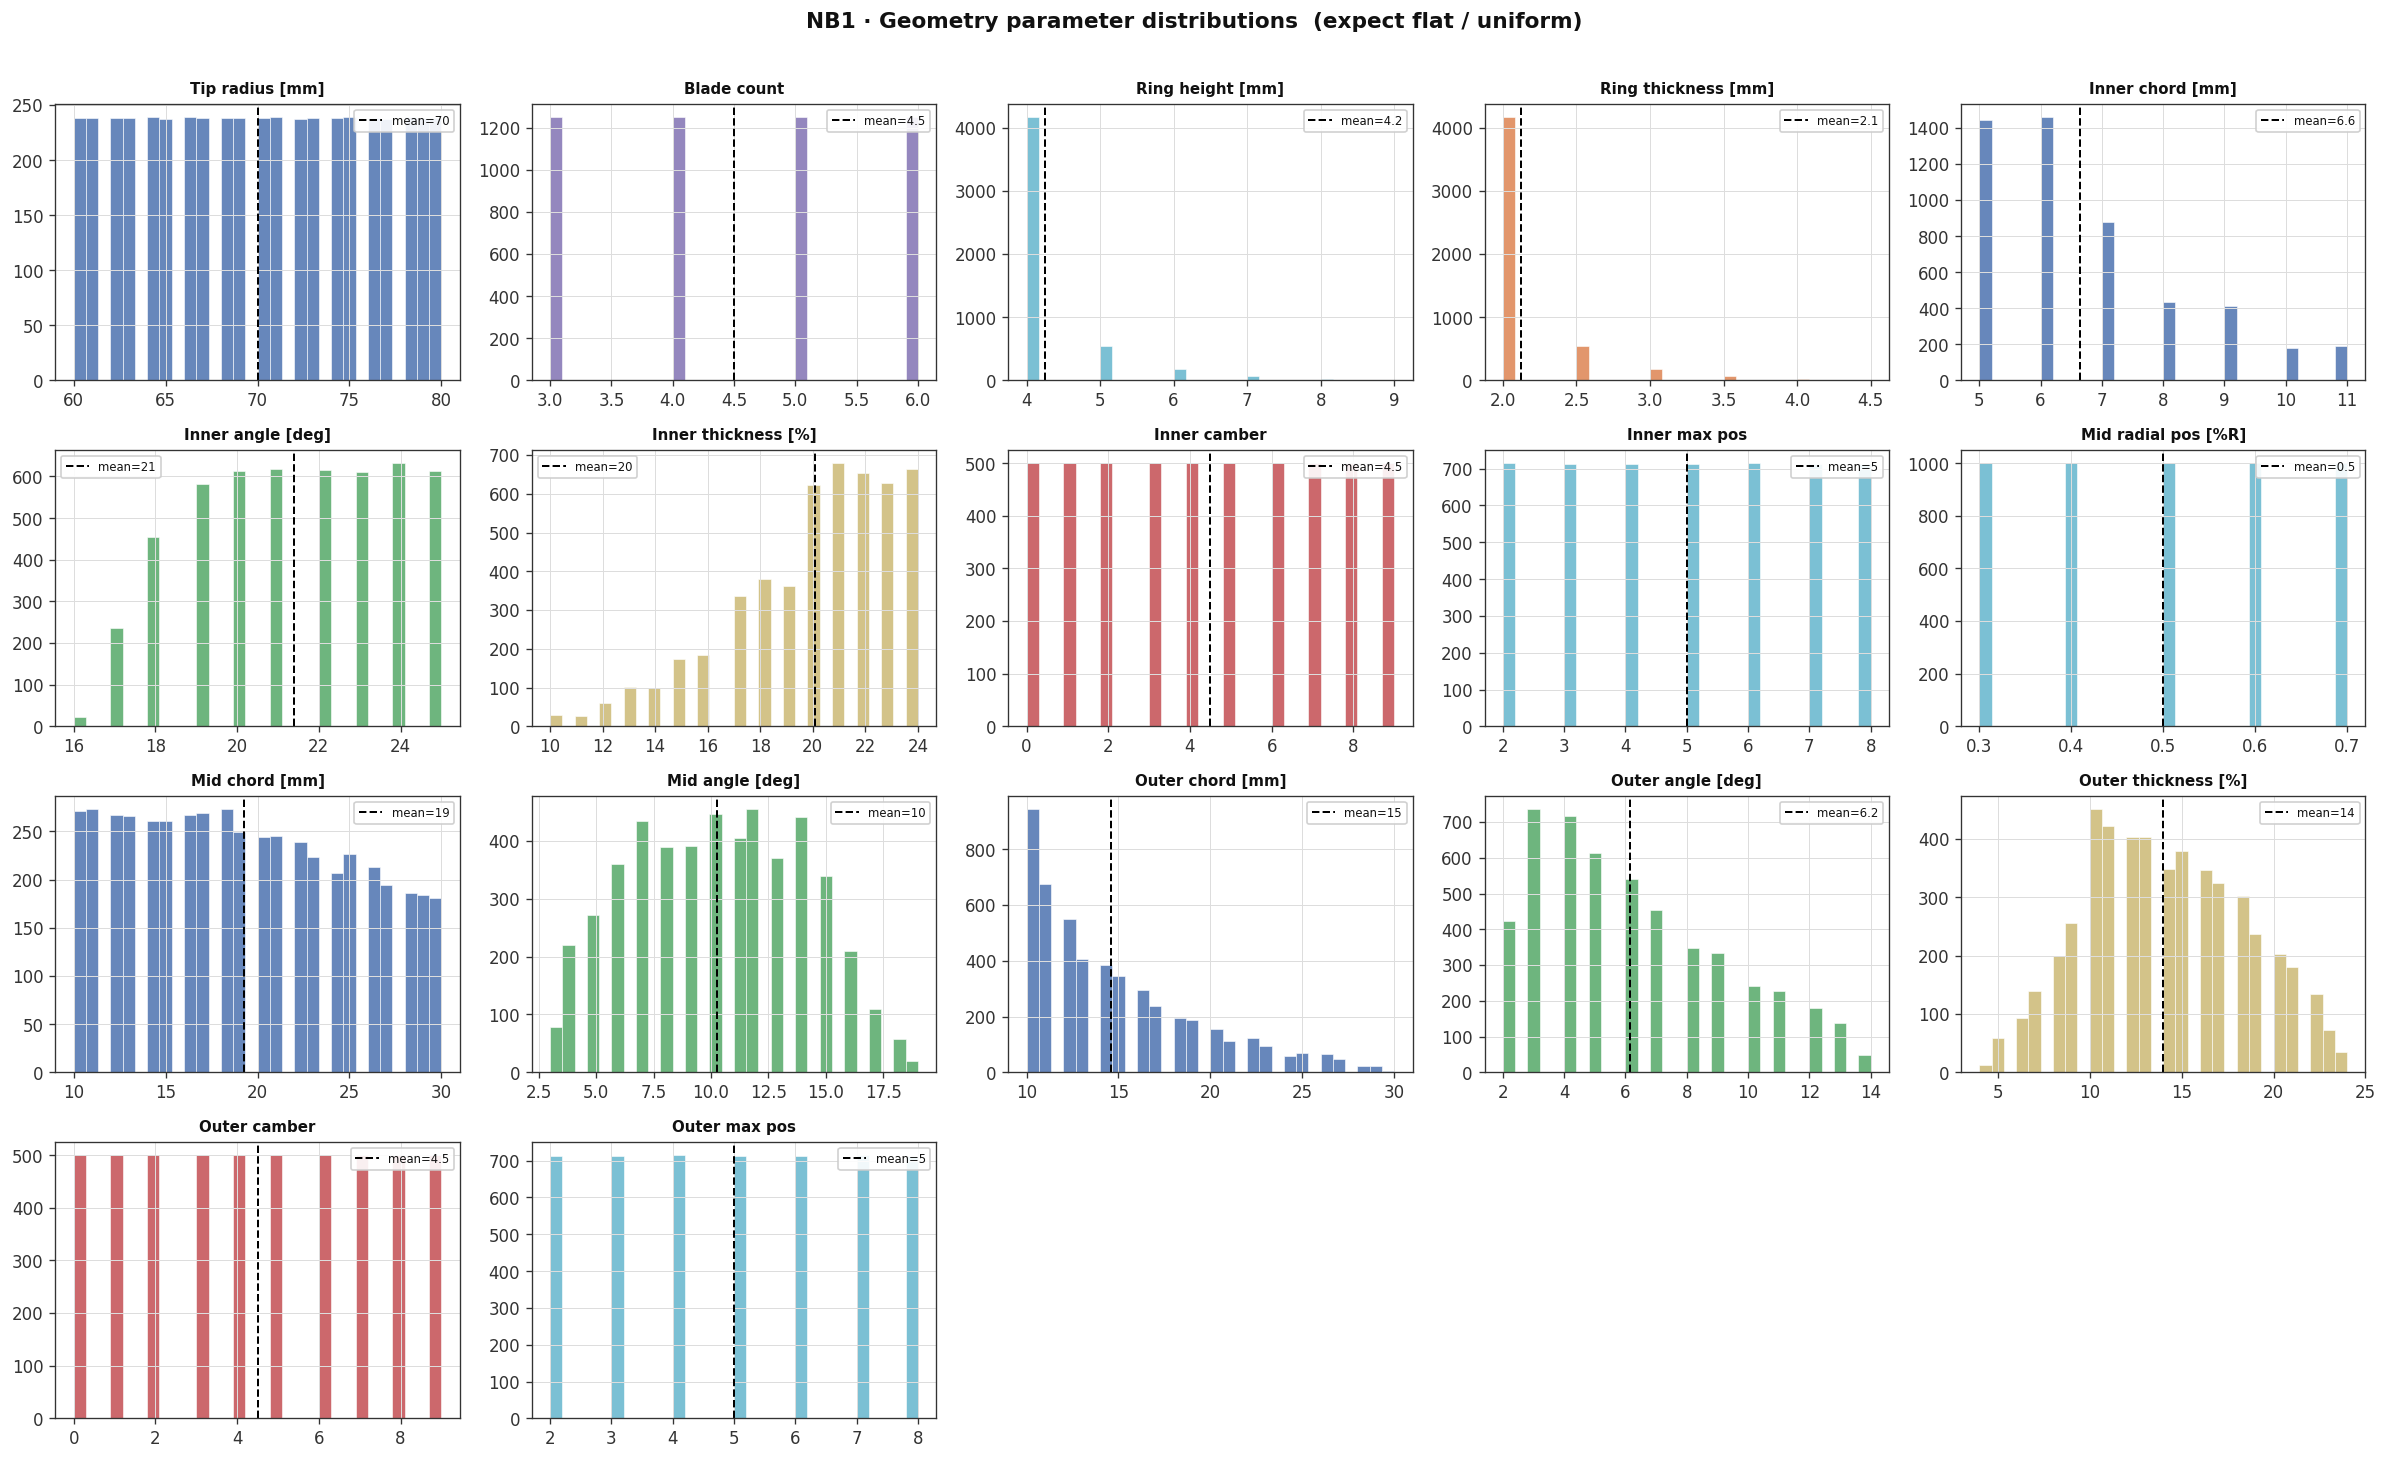

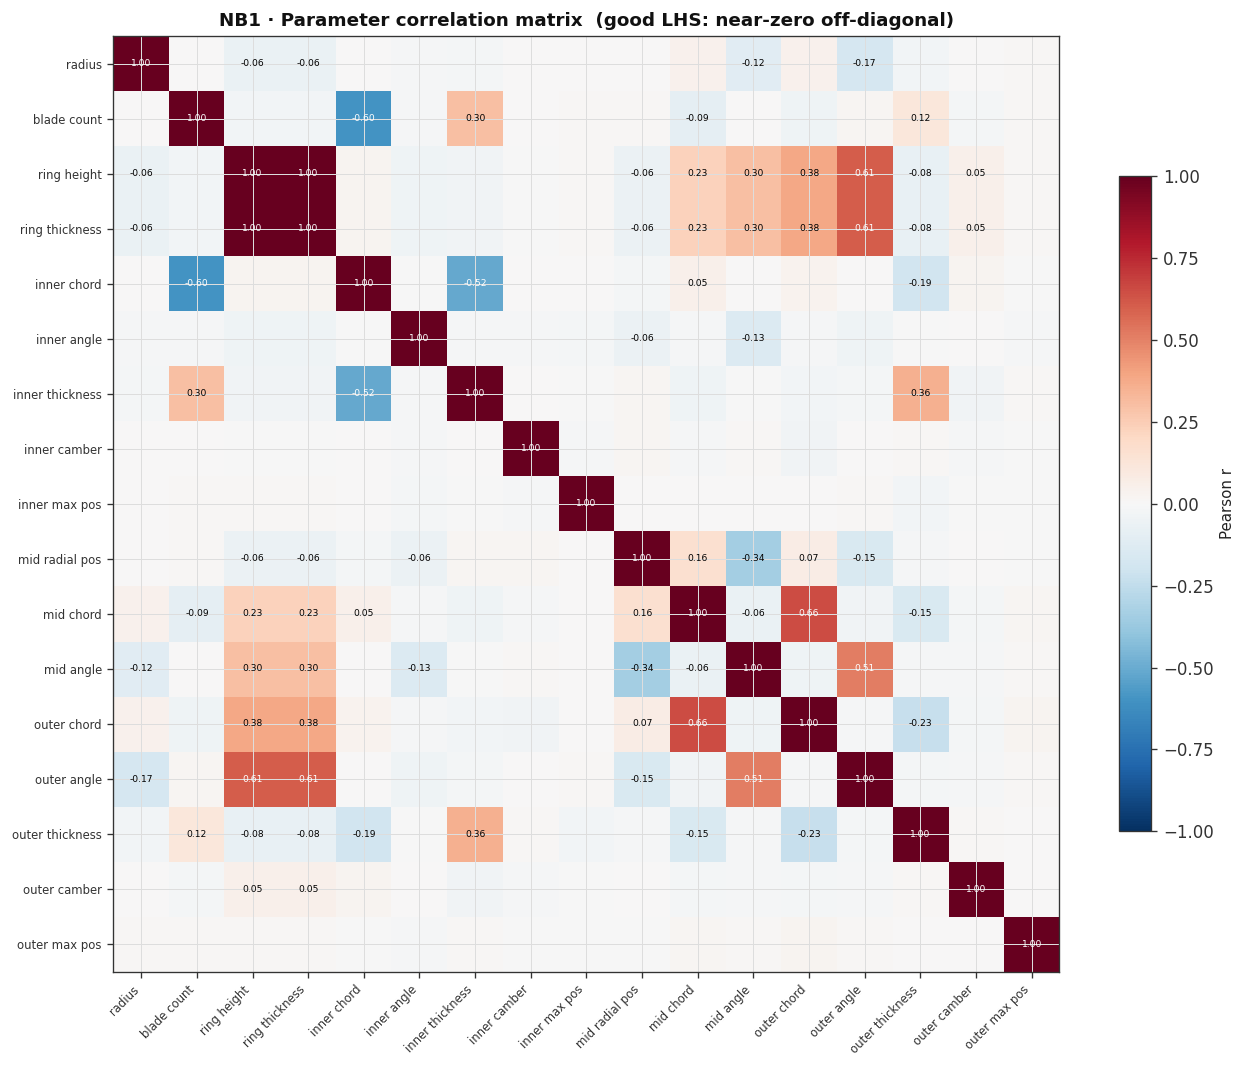

  NOTE: ring_height = 2 x ring_thickness by geometric constraint (r=1.0 expected).
  Largest free-param |r|: 0.656 (mid/outer chord — bounded taper ratio).
  [PASS]  All free-param |r| < 0.70 (no accidental collapse): 1/1  (100.0%)  (max |r| = 0.656)


In [28]:
geo = load('01_geometry.csv')

if geo is not None:
    print('NB1 validation')
    print(f'  Configs generated : {len(geo)}')
    print(f'  Parameters        : {geo.shape[1] - 1}')
    print(f'  Duplicate rows    : {geo.duplicated().sum()}')
    print(f'  Any NaN           : {bool(geo.isna().any().any())}')

    params = [
        ('radius_mm', 'Tip radius [mm]', PALETTE['blue']),
        ('blade_count', 'Blade count', PALETTE['purple']),
        ('ring_height_mm', 'Ring height [mm]', PALETTE['teal']),
        ('ring_thickness_mm', 'Ring thickness [mm]', PALETTE['orange']),
        ('inner_chord_mm', 'Inner chord [mm]', PALETTE['blue']),
        ('inner_angle_deg', 'Inner angle [deg]', PALETTE['green']),
        ('inner_thickness_pct', 'Inner thickness [%]', PALETTE['gold']),
        ('inner_camber', 'Inner camber', PALETTE['red']),
        ('inner_max_pos', 'Inner max pos', PALETTE['teal']),
        ('mid_radial_pos', 'Mid radial pos [%R]', PALETTE['teal']),
        ('mid_chord_mm', 'Mid chord [mm]', PALETTE['blue']),
        ('mid_angle_deg', 'Mid angle [deg]', PALETTE['green']),
        ('outer_chord_mm', 'Outer chord [mm]', PALETTE['blue']),
        ('outer_angle_deg', 'Outer angle [deg]', PALETTE['green']),
        ('outer_thickness_pct', 'Outer thickness [%]', PALETTE['gold']),
        ('outer_camber', 'Outer camber', PALETTE['red']),
        ('outer_max_pos', 'Outer max pos', PALETTE['teal']),
    ]
    available = []
    for column, label, color in params:
        if column in geo.columns:
            available.append((column, label, color))

    ncols = 5
    nrows = (len(available) + 4) // 5
    fig, axes = plt.subplots(nrows, ncols, figsize=(20, 3.0 * nrows))
    fig.suptitle('NB1 · Geometry parameter distributions  (expect flat / uniform)', fontsize=13, fontweight='bold', y=1.01)
    for idx, (column, label, color) in enumerate(available):
        histplot(axes.flat[idx], geo[column], color, label, '')
    for i in range(len(available), nrows * ncols):
        axes.flat[i].axis('off')
    plt.tight_layout()
    savefig('nb1/nb1_geometry_distributions.png')

    num_cols = []
    for column, label, color in available:
        num_cols.append(column)
    corr = geo[num_cols].corr()
    fig, ax = plt.subplots(figsize=(11, 9))
    im = ax.imshow(corr.values, vmin=-1, vmax=1, cmap='RdBu_r', aspect='auto')
    ax.set_xticks(range(len(num_cols)))
    ax.set_yticks(range(len(num_cols)))
    short = []
    for column in num_cols:
        short.append(column.replace('_mm', '').replace('_deg', '').replace('_pct', '').replace('_', ' '))
    ax.set_xticklabels(short, rotation=45, ha='right', fontsize=7)
    ax.set_yticklabels(short, fontsize=7)
    plt.colorbar(im, ax=ax, shrink=0.7, label='Pearson r')
    for i in range(len(num_cols)):
        for j in range(len(num_cols)):
            v = corr.values[i, j]
            if abs(v) > 0.05:
                if abs(v) > 0.5:
                    text_color = 'white'
                else:
                    text_color = 'black'
                ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=5.5, color=text_color)
    ax.set_title('NB1 · Parameter correlation matrix  (good LHS: near-zero off-diagonal)', fontsize=11, fontweight='bold')
    plt.tight_layout()
    savefig('nb1/nb1_correlation_matrix.png')

    free_cols = []
    for column in num_cols:
        if column not in ('ring_height_mm', 'ring_thickness_mm'):
            free_cols.append(column)
    corr_free = geo[free_cols].corr()
    max_free = corr_free.abs().values[np.triu_indices(len(free_cols), k=1)].max()
    print('  NOTE: ring_height = 2 x ring_thickness by geometric constraint (r=1.0 expected).')
    print(f'  Largest free-param |r|: {max_free:.3f} (mid/outer chord — bounded taper ratio).')
    badge('All free-param |r| < 0.70 (no accidental collapse)', int(max_free < 0.70), 1, note=f'(max |r| = {max_free:.3f})')

### 4.2 NB1 — Radial Parameter Evolution

Each propeller's blade parameters vary along the span, reconstructed with the same spline model the pipeline uses (natural cubic spline through inner/mid/outer for chord and twist; inner/outer for thickness, camber and max-camber position). Thin lines show the design-space envelope; the thick line is the mean blade shape.


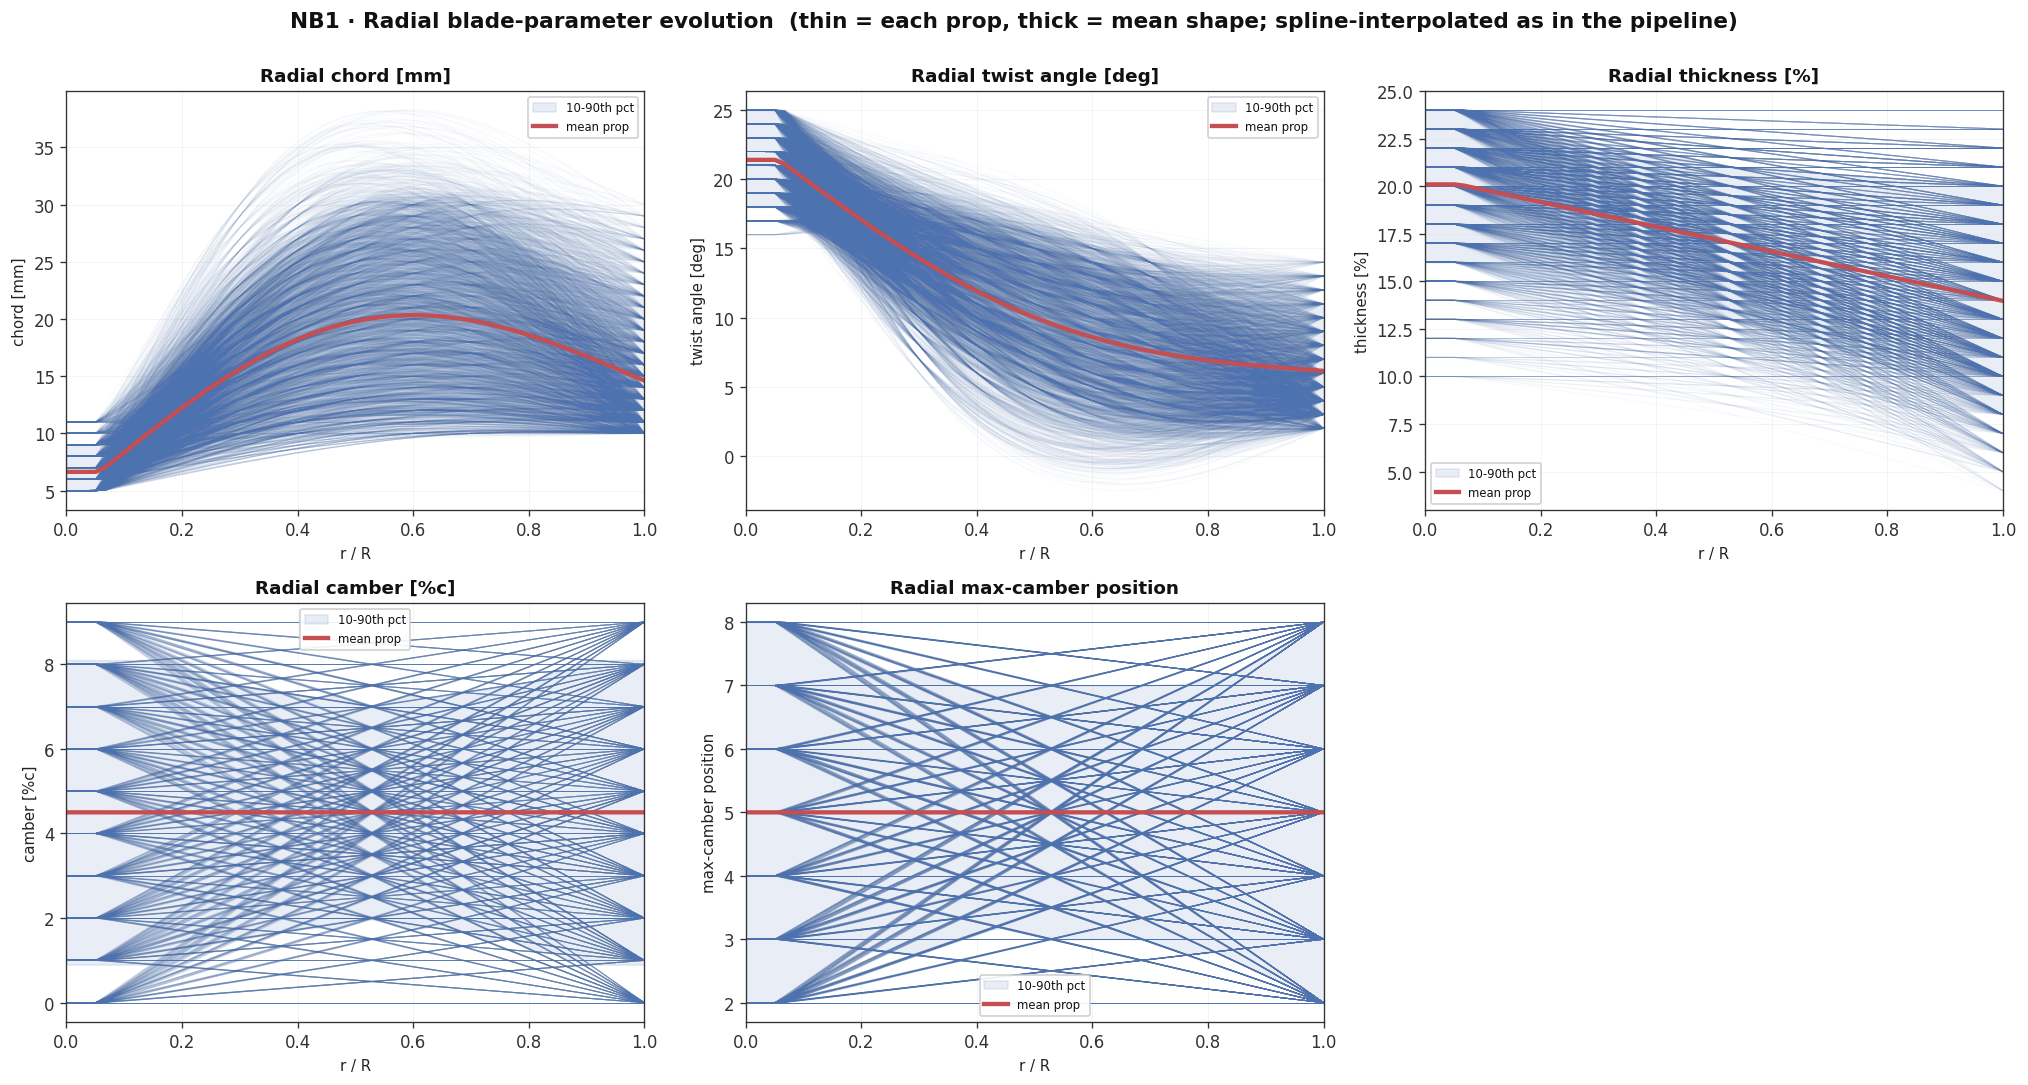

Radial evolution plotted for 5000 propellers (chord & twist: 3-anchor spline; thickness/camber/max-pos: 2-anchor).


In [29]:
geo_r = load('01_geometry.csv')

if geo_r is not None:
    RADIAL_PARAMS = [
        ('chord_mm', 'chord [mm]', 'three'),
        ('angle_deg', 'twist angle [deg]', 'three'),
        ('thickness_pct', 'thickness [%]', 'two'),
        ('camber', 'camber [%c]', 'two'),
        ('max_pos', 'max-camber position', 'two'),
    ]
    N_R = 60

    fig, axes = plt.subplots(2, 3, figsize=(17, 9))
    fig.suptitle('NB1 · Radial blade-parameter evolution  (thin = each prop, thick = mean shape; spline-interpolated as in the pipeline)', fontsize=13, fontweight='bold', y=1.00)

    grid_rR = np.linspace(0, 1, N_R)
    for ax, (param, label, kind) in zip(axes.flat, RADIAL_PARAMS):
        stacked = []
        for row_index, row in geo_r.iterrows():
            rR, vals = radial_profile(row, param, kind, n=N_R)
            if rR is None:
                continue
            vals_on_grid = np.interp(grid_rR, rR, vals)
            ax.plot(grid_rR, vals_on_grid, color=PALETTE['blue'], alpha=0.04, lw=0.6)
            stacked.append(vals_on_grid)
        if stacked:
            mat = np.vstack(stacked)
            mean_curve = np.nanmean(mat, axis=0)
            p10, p90 = np.nanpercentile(mat, [10, 90], axis=0)
            ax.fill_between(grid_rR, p10, p90, color=PALETTE['blue'], alpha=0.12, label='10-90th pct')
            ax.plot(grid_rR, mean_curve, color=PALETTE['red'], lw=2.6, label='mean prop')
        ax.set_xlabel('r / R')
        ax.set_ylabel(label)
        ax.set_title(f'Radial {label}')
        ax.legend(fontsize=7)
        ax.grid(alpha=0.3)
        ax.set_xlim(0, 1)
    axes.flat[-1].axis('off')
    plt.tight_layout()
    savefig('nb1/nb1_radial_evolution.png')
    print(f'Radial evolution plotted for {len(geo_r)} propellers (chord & twist: 3-anchor spline; thickness/camber/max-pos: 2-anchor).')

### 4.3 NB2 / NB3 — STL Volume, Mass and Inertia

NB2 validation
  STLs recorded     : 5000
  stl_ok = True     : 4955  (99.1%)


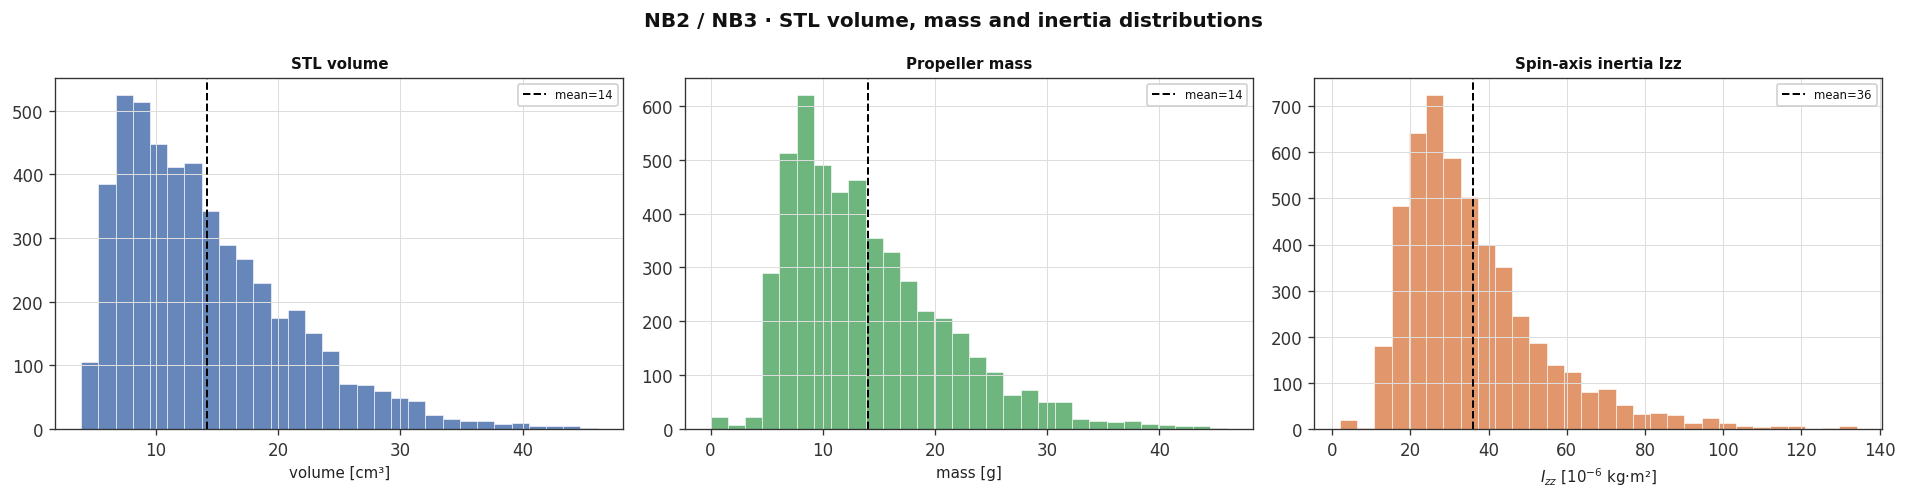

  [PASS]  All STLs valid (single solid, plausible volume): 4955/5000  (99.1%)  


In [30]:
stlv = load('02_stl_volumes.csv')
mi = load('03_mass_inertia.csv')

if stlv is not None:
    if 'volume_L' in stlv.columns:
        vol_col = 'volume_L'
    else:
        vol_col = stlv.columns[1]
    if 'stl_ok' in stlv.columns:
        ok = stlv['stl_ok']
    else:
        ok = pd.Series(True, index=stlv.index)
    print('NB2 validation')
    print(f'  STLs recorded     : {len(stlv)}')
    print(f'  stl_ok = True     : {int(ok.sum())}  ({100 * ok.mean():.1f}%)')

    fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
    if vol_col == 'volume_L':
        volume_values = stlv.loc[ok, vol_col] * 1000
        volume_xlabel = 'volume [cm³]'
    else:
        volume_values = stlv.loc[ok, vol_col]
        volume_xlabel = vol_col
    histplot(axes[0], volume_values, PALETTE['blue'], 'STL volume', volume_xlabel)
    if mi is not None and 'mass_g' in mi.columns:
        histplot(axes[1], mi['mass_g'], PALETTE['green'], 'Propeller mass', 'mass [g]')
        if 'izz_regressed' in mi.columns:
            izz_col = 'izz_regressed'
        else:
            izz_col = 'izz'
        histplot(axes[2], mi[izz_col] * 1e6, PALETTE['orange'], 'Spin-axis inertia Izz', r'$I_{zz}$ [$10^{-6}$ kg·m²]')
    else:
        axes[1].axis('off')
        axes[2].axis('off')
    fig.suptitle('NB2 / NB3 · STL volume, mass and inertia distributions', fontsize=12, fontweight='bold')
    plt.tight_layout()
    savefig('nb2/nb2_mass_volume.png')
    badge('All STLs valid (single solid, plausible volume)', int(ok.sum()), len(stlv))

### 4.4 NB4 — XFoil Polar Quality

Three views, resolved per blade station: the tier composition at each station, the convergence rate versus Reynolds number (which exposes XFoil's difficulty at the very low Re of the inner stations), and the per-design thrust-weighted confidence score.


NB4 validation
  Configs with polars : 5000
  Mean confidence     : 0.934
  Configs >= 0.5 gate : 4929  (98.6%)


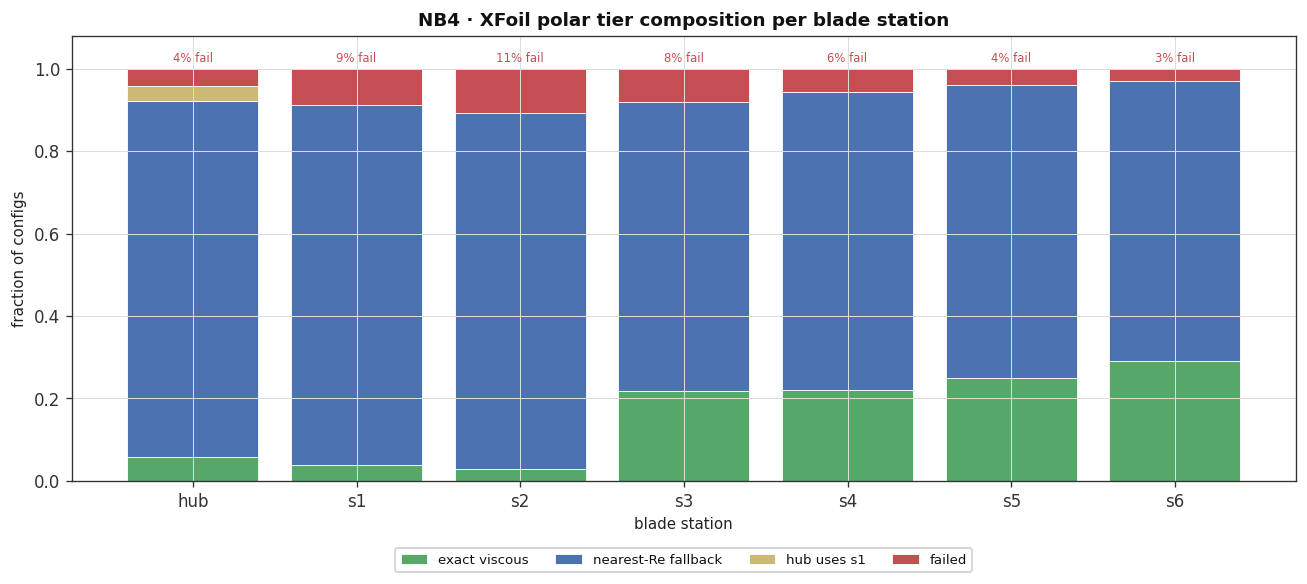

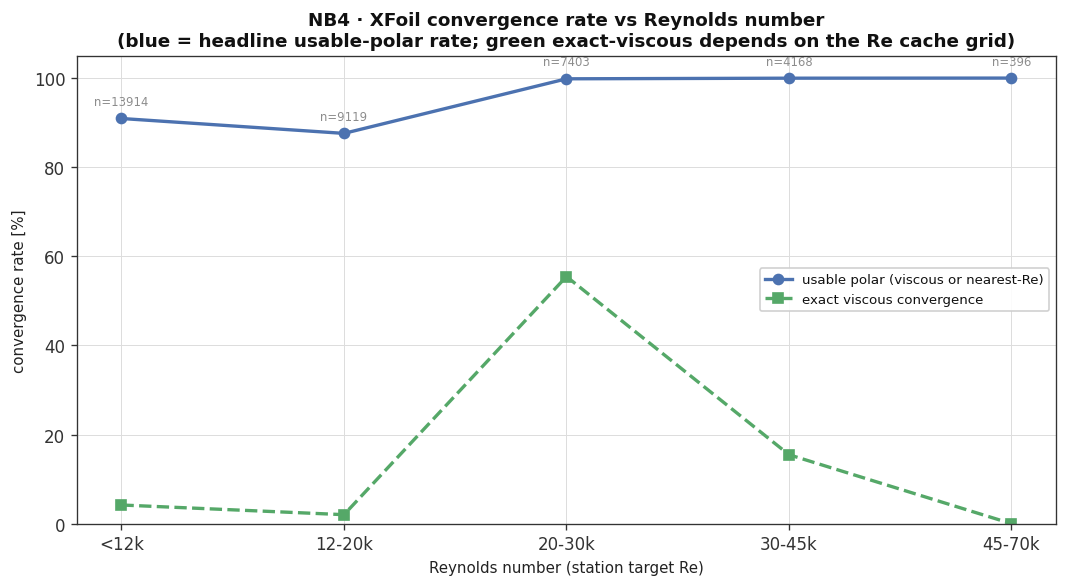

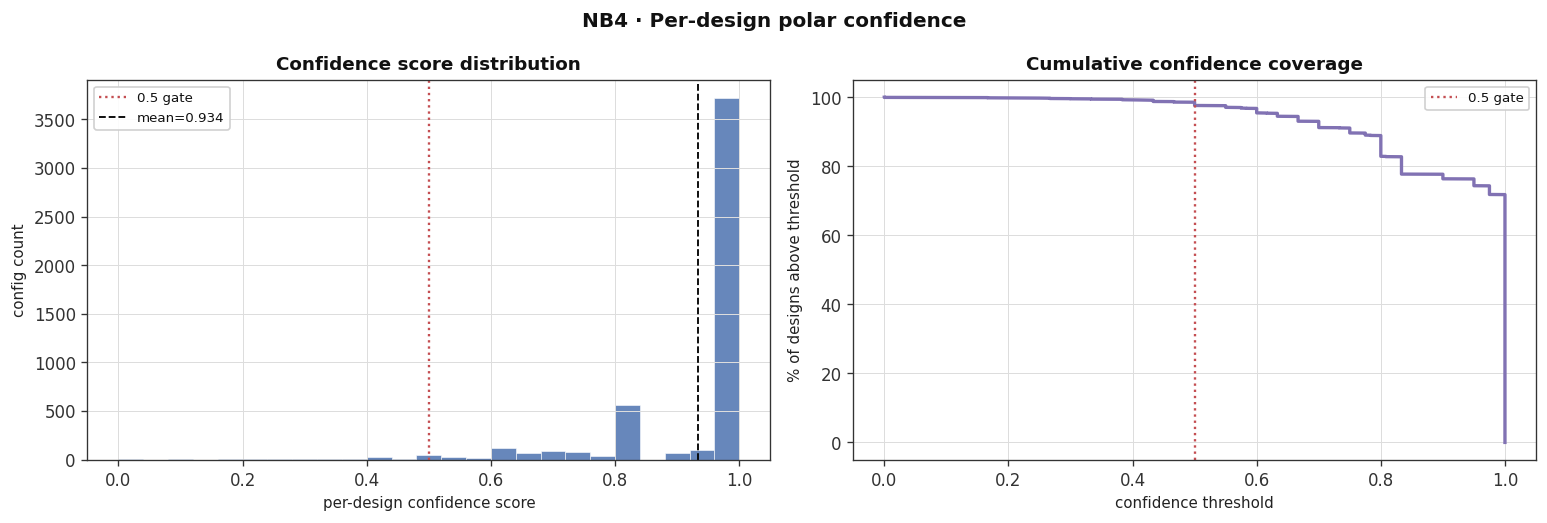

  [PASS]  Configs above confidence gate (>=0.5): 4929/5000  (98.6%)  


In [31]:
xf = load('04_xfoil_polars.csv')

if xf is not None:
    STATIONS = []
    for s in ['hub', 's1', 's2', 's3', 's4', 's5', 's6']:
        if f'tier_{s}' in xf.columns:
            STATIONS.append(s)
    TIER_ORDER = ['viscous', 'viscous_near_re', 'hub_uses_s1', 'failed']
    TIER_COLORS = {'viscous': PALETTE['green'], 'viscous_near_re': PALETTE['blue'], 'hub_uses_s1': PALETTE['gold'], 'failed': PALETTE['red']}
    TIER_LABEL = {'viscous': 'exact viscous', 'viscous_near_re': 'nearest-Re fallback', 'hub_uses_s1': 'hub uses s1', 'failed': 'failed'}

    print('NB4 validation')
    print(f'  Configs with polars : {len(xf)}')
    if 'confidence_score' in xf.columns:
        print(f"  Mean confidence     : {xf['confidence_score'].mean():.3f}")
        print(f"  Configs >= 0.5 gate : {int((xf['confidence_score'] >= 0.5).sum())}  ({100 * (xf['confidence_score'] >= 0.5).mean():.1f}%)")

    tier_count_columns = {}
    for s in STATIONS:
        tier_count_columns[s] = xf[f'tier_{s}'].value_counts()
    comp = pd.DataFrame(tier_count_columns).fillna(0).astype(int).T
    ordered_tiers = []
    for t in TIER_ORDER:
        if t in comp.columns:
            ordered_tiers.append(t)
    comp = comp.reindex(columns=ordered_tiers)
    frac = comp.div(comp.sum(axis=1), axis=0)

    fig, ax = plt.subplots(figsize=(11, 5))
    bottom = np.zeros(len(STATIONS))
    for tier in comp.columns:
        ax.bar(STATIONS, frac[tier].values, bottom=bottom, color=TIER_COLORS[tier], edgecolor='white', linewidth=0.5, label=TIER_LABEL[tier])
        bottom += frac[tier].values
    for i, s in enumerate(STATIONS):
        if 'failed' in frac.columns:
            fail_pct = frac.loc[s, 'failed'] * 100
        else:
            fail_pct = 0
        ax.text(i, 1.01, f'{fail_pct:.0f}% fail', ha='center', va='bottom', fontsize=7, color=PALETTE['red'])
    ax.set_ylim(0, 1.08)
    ax.set_ylabel('fraction of configs')
    ax.set_xlabel('blade station')
    ax.set_title('NB4 · XFoil polar tier composition per blade station')
    ax.legend(fontsize=8, ncol=4, loc='lower center', bbox_to_anchor=(0.5, -0.22))
    plt.tight_layout()
    savefig('nb4/nb4_tier_per_station.png')

    pooled_frames = []
    for s in STATIONS:
        sub = xf[[f're_{s}', f'tier_{s}']].dropna()
        sub.columns = ['re', 'tier']
        pooled_frames.append(sub)
    pooled = pd.concat(pooled_frames, ignore_index=True)
    pooled['usable'] = pooled['tier'].isin(['viscous', 'viscous_near_re'])
    pooled['exact'] = pooled['tier'] == 'viscous'
    bins = [0, 12000, 20000, 30000, 45000, 70000, 1e9]
    labels = ['<12k', '12-20k', '20-30k', '30-45k', '45-70k', '>70k']
    pooled['re_bin'] = pd.cut(pooled['re'], bins=bins, labels=labels)
    conv = pooled.groupby('re_bin', observed=True).agg(n=('usable', 'size'), usable_rate=('usable', 'mean'), exact_rate=('exact', 'mean')).reset_index()
    conv = conv[conv['n'] > 0]

    fig, ax = plt.subplots(figsize=(9, 5))
    x = np.arange(len(conv))
    ax.plot(x, conv['usable_rate'] * 100, 'o-', color=PALETTE['blue'], lw=2, label='usable polar (viscous or nearest-Re)')
    ax.plot(x, conv['exact_rate'] * 100, 's--', color=PALETTE['green'], lw=2, label='exact viscous convergence')
    for i in range(len(conv)):
        ax.annotate(f"n={int(conv['n'].iloc[i])}", (i, conv['usable_rate'].iloc[i] * 100), textcoords='offset points', xytext=(0, 8), ha='center', fontsize=7, color=PALETTE['grey'])
    ax.set_xticks(x)
    ax.set_xticklabels(conv['re_bin'])
    ax.set_ylim(0, 105)
    ax.set_xlabel('Reynolds number (station target Re)')
    ax.set_ylabel('convergence rate [%]')
    ax.set_title('NB4 · XFoil convergence rate vs Reynolds number\n(blue = headline usable-polar rate; green exact-viscous depends on the Re cache grid)')
    ax.legend(fontsize=8)
    plt.tight_layout()
    savefig('nb4/nb4_convergence_vs_re.png')

    if 'confidence_score' in xf.columns:
        fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
        axes[0].hist(xf['confidence_score'], bins=25, color=PALETTE['blue'], alpha=0.85, edgecolor='white', linewidth=0.4)
        axes[0].axvline(0.5, color=PALETTE['red'], ls=':', lw=1.4, label='0.5 gate')
        axes[0].axvline(xf['confidence_score'].mean(), color='black', ls='--', lw=1.1, label=f"mean={xf['confidence_score'].mean():.3f}")
        axes[0].set_xlabel('per-design confidence score')
        axes[0].set_ylabel('config count')
        axes[0].set_title('Confidence score distribution')
        axes[0].legend(fontsize=8)
        sorted_c = np.sort(xf['confidence_score'].values)
        frac_above = 1 - np.arange(len(sorted_c)) / len(sorted_c)
        axes[1].plot(sorted_c, frac_above * 100, color=PALETTE['purple'], lw=2)
        axes[1].axvline(0.5, color=PALETTE['red'], ls=':', lw=1.4, label='0.5 gate')
        axes[1].set_xlabel('confidence threshold')
        axes[1].set_ylabel('% of designs above threshold')
        axes[1].set_title('Cumulative confidence coverage')
        axes[1].legend(fontsize=8)
        fig.suptitle('NB4 · Per-design polar confidence', fontsize=12, fontweight='bold')
        plt.tight_layout()
        savefig('nb4/nb4_confidence_distribution.png')
        badge('Configs above confidence gate (>=0.5)', int((xf['confidence_score'] >= 0.5).sum()), len(xf))

### 4.5 NB5 — QProp Performance

Key hover and optimum-efficiency performance metrics across the design space, plus the 3-D thrust and torque operating surfaces of the reference propeller (config 885) — the 2-D tables the flight ODE interpolates. Thrust rises steeply with RPM (≈ω²) and falls with forward speed (advance-ratio unloading).


NB5 validation
  Configs with QProp data : 5000
  qprop_ok = True         : 4442  (88.8%)


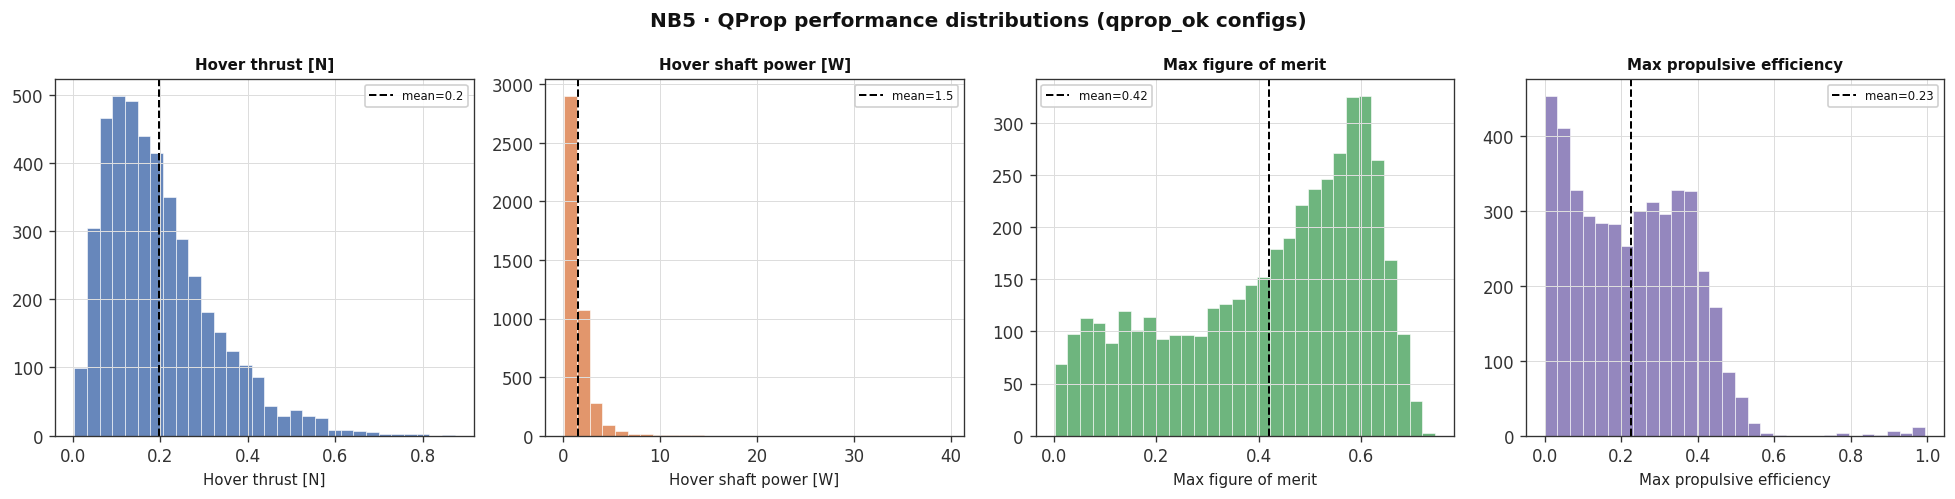

  [WARN]  Configs with valid QProp performance: 4442/5000  (88.8%)  


In [32]:
qres = load('05_qprop_results.csv')

if qres is not None:
    if 'qprop_ok' in qres.columns:
        ok = qres['qprop_ok']
    else:
        ok = pd.Series(True, index=qres.index)
    q = qres[ok]
    print('NB5 validation')
    print(f'  Configs with QProp data : {len(qres)}')
    print(f'  qprop_ok = True         : {int(ok.sum())}  ({100 * ok.mean():.1f}%)')

    panel_candidates = [('T_hover', 'Hover thrust [N]', PALETTE['blue']),
                        ('P_hover', 'Hover shaft power [W]', PALETTE['orange']),
                        ('FOM_max', 'Max figure of merit', PALETTE['green']),
                        ('eta_max', 'Max propulsive efficiency', PALETTE['purple'])]
    panels = []
    for column, label, color in panel_candidates:
        if column in q.columns:
            panels.append((column, label, color))
    fig, axes = plt.subplots(1, len(panels), figsize=(4.1 * len(panels), 4.2))
    for ax, (column, label, color) in zip(np.atleast_1d(axes), panels):
        histplot(ax, q[column], color, label, label)
    fig.suptitle('NB5 · QProp performance distributions (qprop_ok configs)', fontsize=12, fontweight='bold')
    plt.tight_layout()
    savefig('nb5/nb5_qprop_performance.png')
    badge('Configs with valid QProp performance', int(ok.sum()), len(qres))

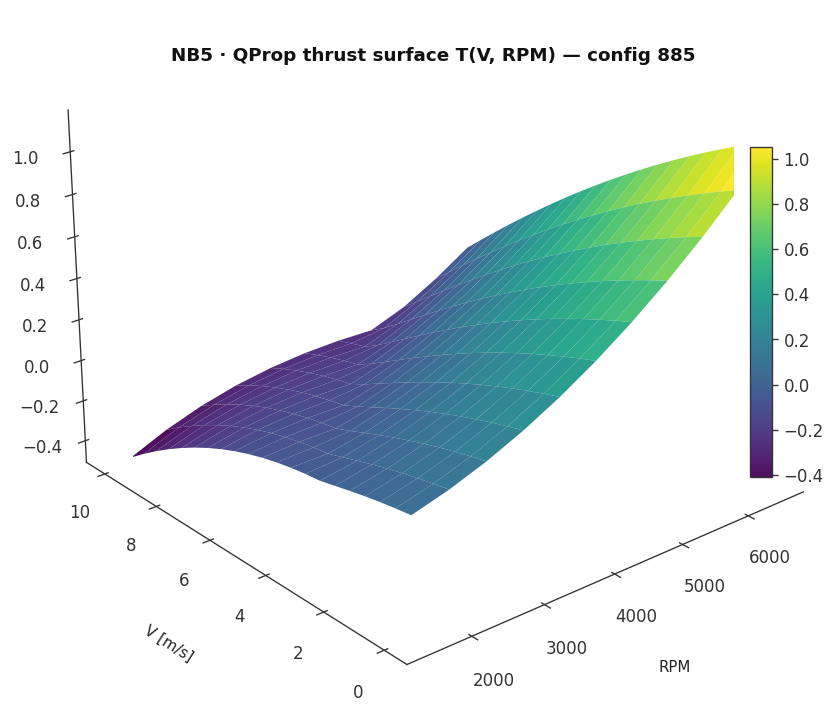

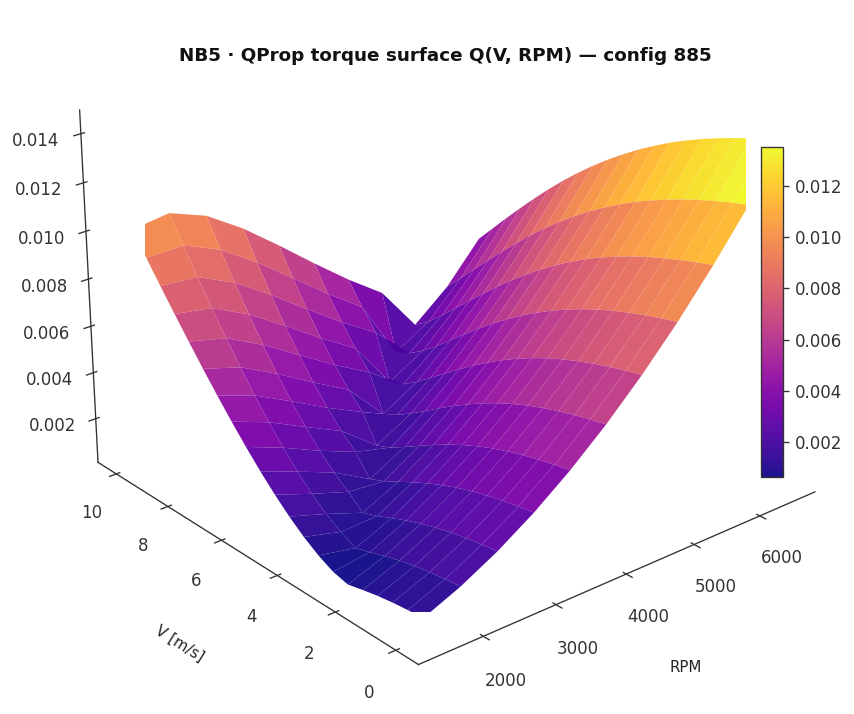

Saved -> plots/nb5/nb5_surface_885_thrust.png and nb5_surface_885_torque.png


In [33]:
SWEEP_PATH = CSV / '05_qprop_sweep.csv.gz'
SURFACE_CONFIG = 885

if not SWEEP_PATH.exists():
    print(f'  [SKIP] {SWEEP_PATH.name} not found — run NB5 first.')
else:
    sweep = pd.read_csv(SWEEP_PATH, usecols=['config_id', 'V', 'rpm', 'T', 'Q', 'qprop_ok'])
    cfg_sweep = sweep[(sweep['config_id'] == SURFACE_CONFIG) & (sweep['qprop_ok'])]
    if cfg_sweep.empty:
        print(f'  [SKIP] no sweep data for config {SURFACE_CONFIG}.')
    else:
        plot_surface_box(cfg_sweep, 'T', 'thrust T [N]', 'viridis', 'nb5/nb5_surface_885_thrust.png', f'NB5 · QProp thrust surface T(V, RPM) — config {SURFACE_CONFIG}')
        plot_surface_box(cfg_sweep, 'Q', 'torque Q [N·m]', 'plasma', 'nb5/nb5_surface_885_torque.png', f'NB5 · QProp torque surface Q(V, RPM) — config {SURFACE_CONFIG}')
        print('Saved -> plots/nb5/nb5_surface_885_thrust.png and nb5_surface_885_torque.png')

### 4.6 NB6 / NB6b — Flight Dynamics: Aero-Only vs Screw-Release

`h_max_aero` is the uncorrected aerodynamic climb (NB6); `h_max` is the screw-release-corrected height (NB6b) that the launcher actually achieves. The correction caps height far below the aero prediction — the design's true differentiator is the aero height, while the corrected height is what is compared to the rig.


NB6 / NB6b validation (reference launch RPM)
  Configs simulated   : 5000
  Can lift off        : 2954


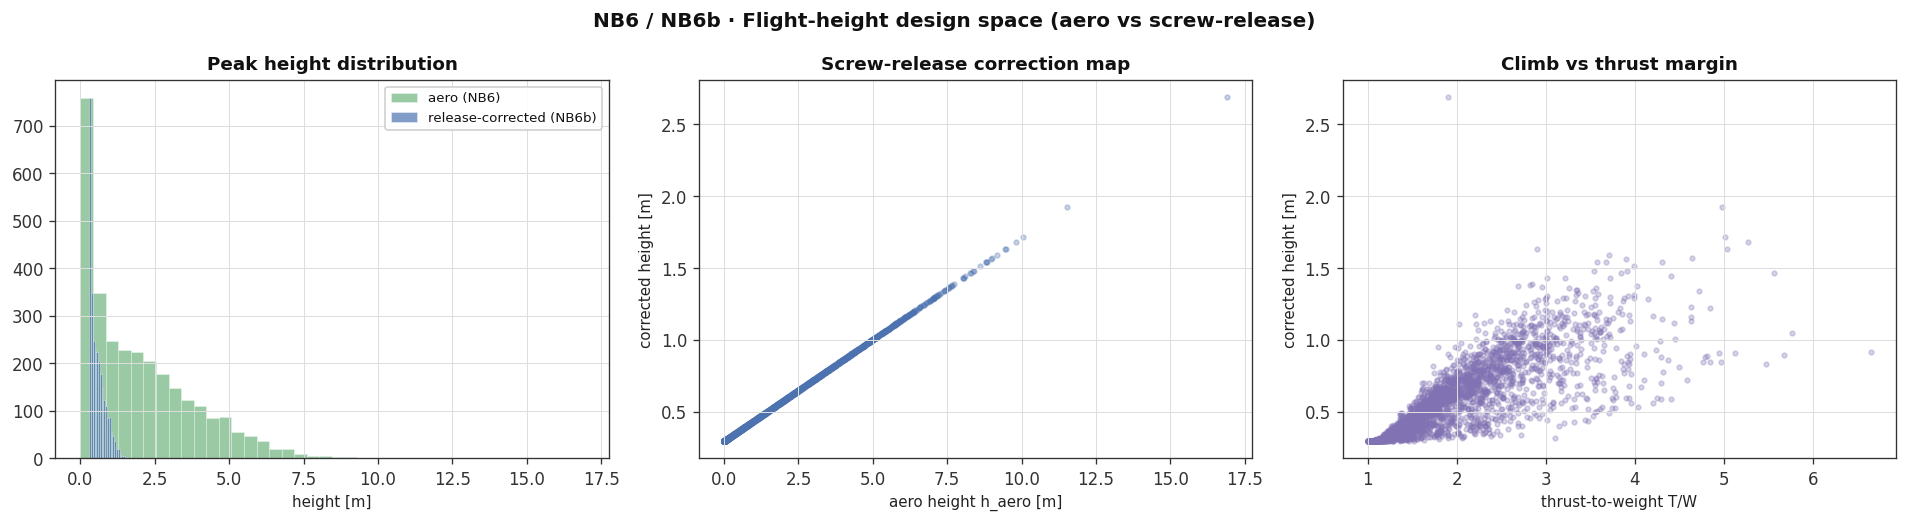

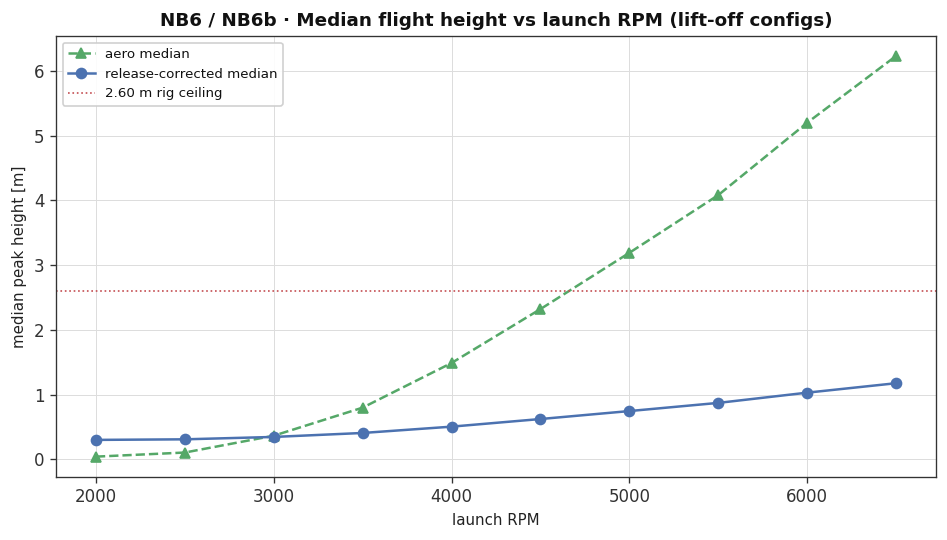

In [34]:
dyn_aero = load('06_flight_dynamics.csv')
dyn_rel = load('06b_flight_dynamics_release.csv')

if dyn_rel is not None:
    if 'can_liftoff' in dyn_rel.columns:
        fly = dyn_rel[dyn_rel['can_liftoff'] == True]
    else:
        fly = dyn_rel
    print('NB6 / NB6b validation (reference launch RPM)')
    print(f'  Configs simulated   : {len(dyn_rel)}')
    print(f"  Can lift off        : {int((dyn_rel.get('can_liftoff', pd.Series(False)) == True).sum())}")

    fig, axes = plt.subplots(1, 3, figsize=(16, 4.4))
    if 'h_max_aero_m' in fly.columns:
        axes[0].hist(fly['h_max_aero_m'].dropna(), bins=40, color=PALETTE['green'], alpha=0.6, label='aero (NB6)', edgecolor='white', linewidth=0.3)
    axes[0].hist(fly['h_max_m'].dropna(), bins=40, color=PALETTE['blue'], alpha=0.7, label='release-corrected (NB6b)', edgecolor='white', linewidth=0.3)
    axes[0].set_title('Peak height distribution')
    axes[0].set_xlabel('height [m]')
    axes[0].legend(fontsize=8)
    if 'h_max_aero_m' in fly.columns:
        axes[1].scatter(fly['h_max_aero_m'], fly['h_max_m'], s=8, alpha=0.3, color=PALETTE['blue'])
        axes[1].set_xlabel('aero height h_aero [m]')
        axes[1].set_ylabel('corrected height [m]')
        axes[1].set_title('Screw-release correction map')
    if 'T_over_W' in fly.columns:
        axes[2].scatter(fly['T_over_W'], fly['h_max_m'], s=8, alpha=0.3, color=PALETTE['purple'])
        axes[2].set_xlabel('thrust-to-weight T/W')
        axes[2].set_ylabel('corrected height [m]')
        axes[2].set_title('Climb vs thrust margin')
    fig.suptitle('NB6 / NB6b · Flight-height design space (aero vs screw-release)', fontsize=12, fontweight='bold')
    plt.tight_layout()
    savefig('nb6/nb6_flight_height.png')

    rpm_files = sorted(CSV.glob('06b_flight_dynamics_release_*rpm.csv'))
    if rpm_files:
        rows = []
        for f in rpm_files:
            m = re.search(r'_(\d+)rpm', f.name)
            d = pd.read_csv(f)
            fl = d[d.get('can_liftoff', False) == True]
            if 'h_max_aero_m' in fl:
                h_aero_median = fl['h_max_aero_m'].median()
            else:
                h_aero_median = np.nan
            rows.append({'rpm': int(m.group(1)), 'h_corr_median': fl['h_max_m'].median(), 'h_aero_median': h_aero_median, 'n_liftoff': len(fl)})
        sweep_rpm = pd.DataFrame(rows).sort_values('rpm')
        fig, ax = plt.subplots(figsize=(8, 4.6))
        ax.plot(sweep_rpm['rpm'], sweep_rpm['h_aero_median'], '^--', color=PALETTE['green'], label='aero median')
        ax.plot(sweep_rpm['rpm'], sweep_rpm['h_corr_median'], 'o-', color=PALETTE['blue'], label='release-corrected median')
        ax.axhline(2.60, color=PALETTE['red'], ls=':', lw=1, label='2.60 m rig ceiling')
        ax.set_xlabel('launch RPM')
        ax.set_ylabel('median peak height [m]')
        ax.set_title('NB6 / NB6b · Median flight height vs launch RPM (lift-off configs)')
        ax.legend(fontsize=8)
        plt.tight_layout()
        savefig('nb6/nb6_height_vs_rpm.png')

### 4.7 NB7 — Representative-Subset Design-Space Coverage

NB7 validation
  Population : 5000
  Selected   : 100


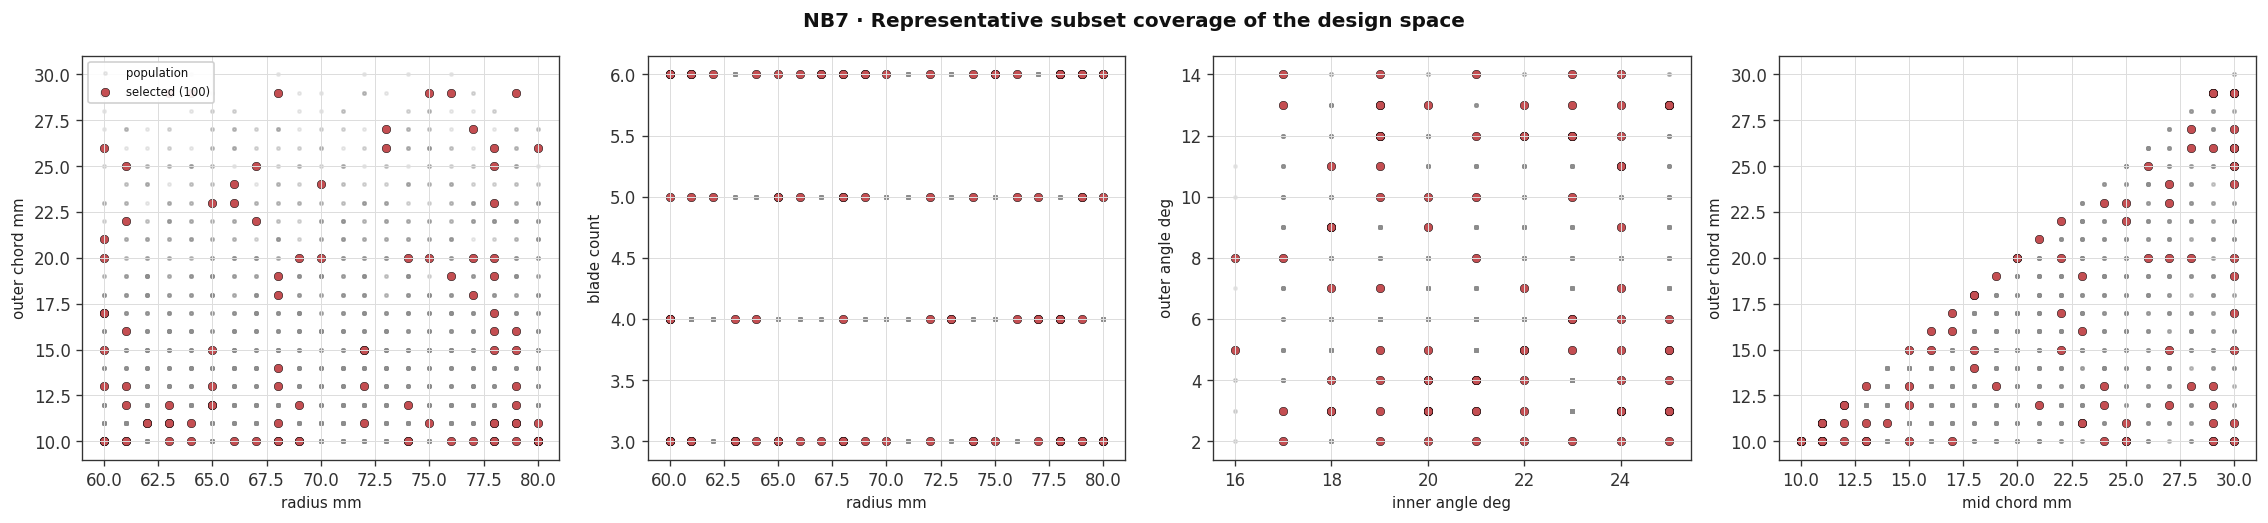

  [PASS]  Selected subset spans >= 90% of each parameter range: 1/1  (100.0%)  (mean coverage 99%)


In [35]:
geo_c = load('01_geometry.csv')
sel = load('07_selected.csv')

if geo_c is not None and sel is not None:
    sel_ids = set(sel['config_id'])
    geo_c['selected'] = geo_c['config_id'].isin(sel_ids)
    print('NB7 validation')
    print(f'  Population : {len(geo_c)}')
    print(f'  Selected   : {len(sel_ids)}')

    projections = [('radius_mm', 'outer_chord_mm'), ('radius_mm', 'blade_count'), ('inner_angle_deg', 'outer_angle_deg'), ('mid_chord_mm', 'outer_chord_mm')]
    fig, axes = plt.subplots(1, 4, figsize=(19, 4.4))
    for ax, (xc, yc) in zip(axes, projections):
        bg = geo_c[~geo_c['selected']]
        fg = geo_c[geo_c['selected']]
        ax.scatter(bg[xc], bg[yc], s=4, alpha=0.15, color=PALETTE['grey'], label='population')
        ax.scatter(fg[xc], fg[yc], s=26, color=PALETTE['red'], edgecolor='black', linewidth=0.3, label='selected (100)')
        ax.set_xlabel(xc.replace('_', ' '))
        ax.set_ylabel(yc.replace('_', ' '))
    axes[0].legend(fontsize=7, loc='upper left')
    fig.suptitle('NB7 · Representative subset coverage of the design space', fontsize=12, fontweight='bold')
    plt.tight_layout()
    savefig('nb7/nb7_selection_coverage.png')

    feats = []
    for f in ['radius_mm', 'blade_count', 'inner_chord_mm', 'outer_chord_mm', 'inner_angle_deg', 'outer_angle_deg', 'mid_radial_pos']:
        if f in geo_c.columns:
            feats.append(f)
    spans = []
    for f in feats:
        pop_rng = geo_c[f].max() - geo_c[f].min()
        if f in sel.columns:
            sel_rng = sel[f].max() - sel[f].min()
        else:
            sel_rng = geo_c.loc[geo_c['selected'], f].max() - geo_c.loc[geo_c['selected'], f].min()
        if pop_rng:
            spans.append(sel_rng / pop_rng)
        else:
            spans.append(np.nan)
    cover = np.nanmean(spans)
    badge('Selected subset spans >= 90% of each parameter range', int(cover >= 0.9), 1, note=f'(mean coverage {100 * cover:.0f}%)')

### 4.8 Full-Pipeline Correlation Across Stages

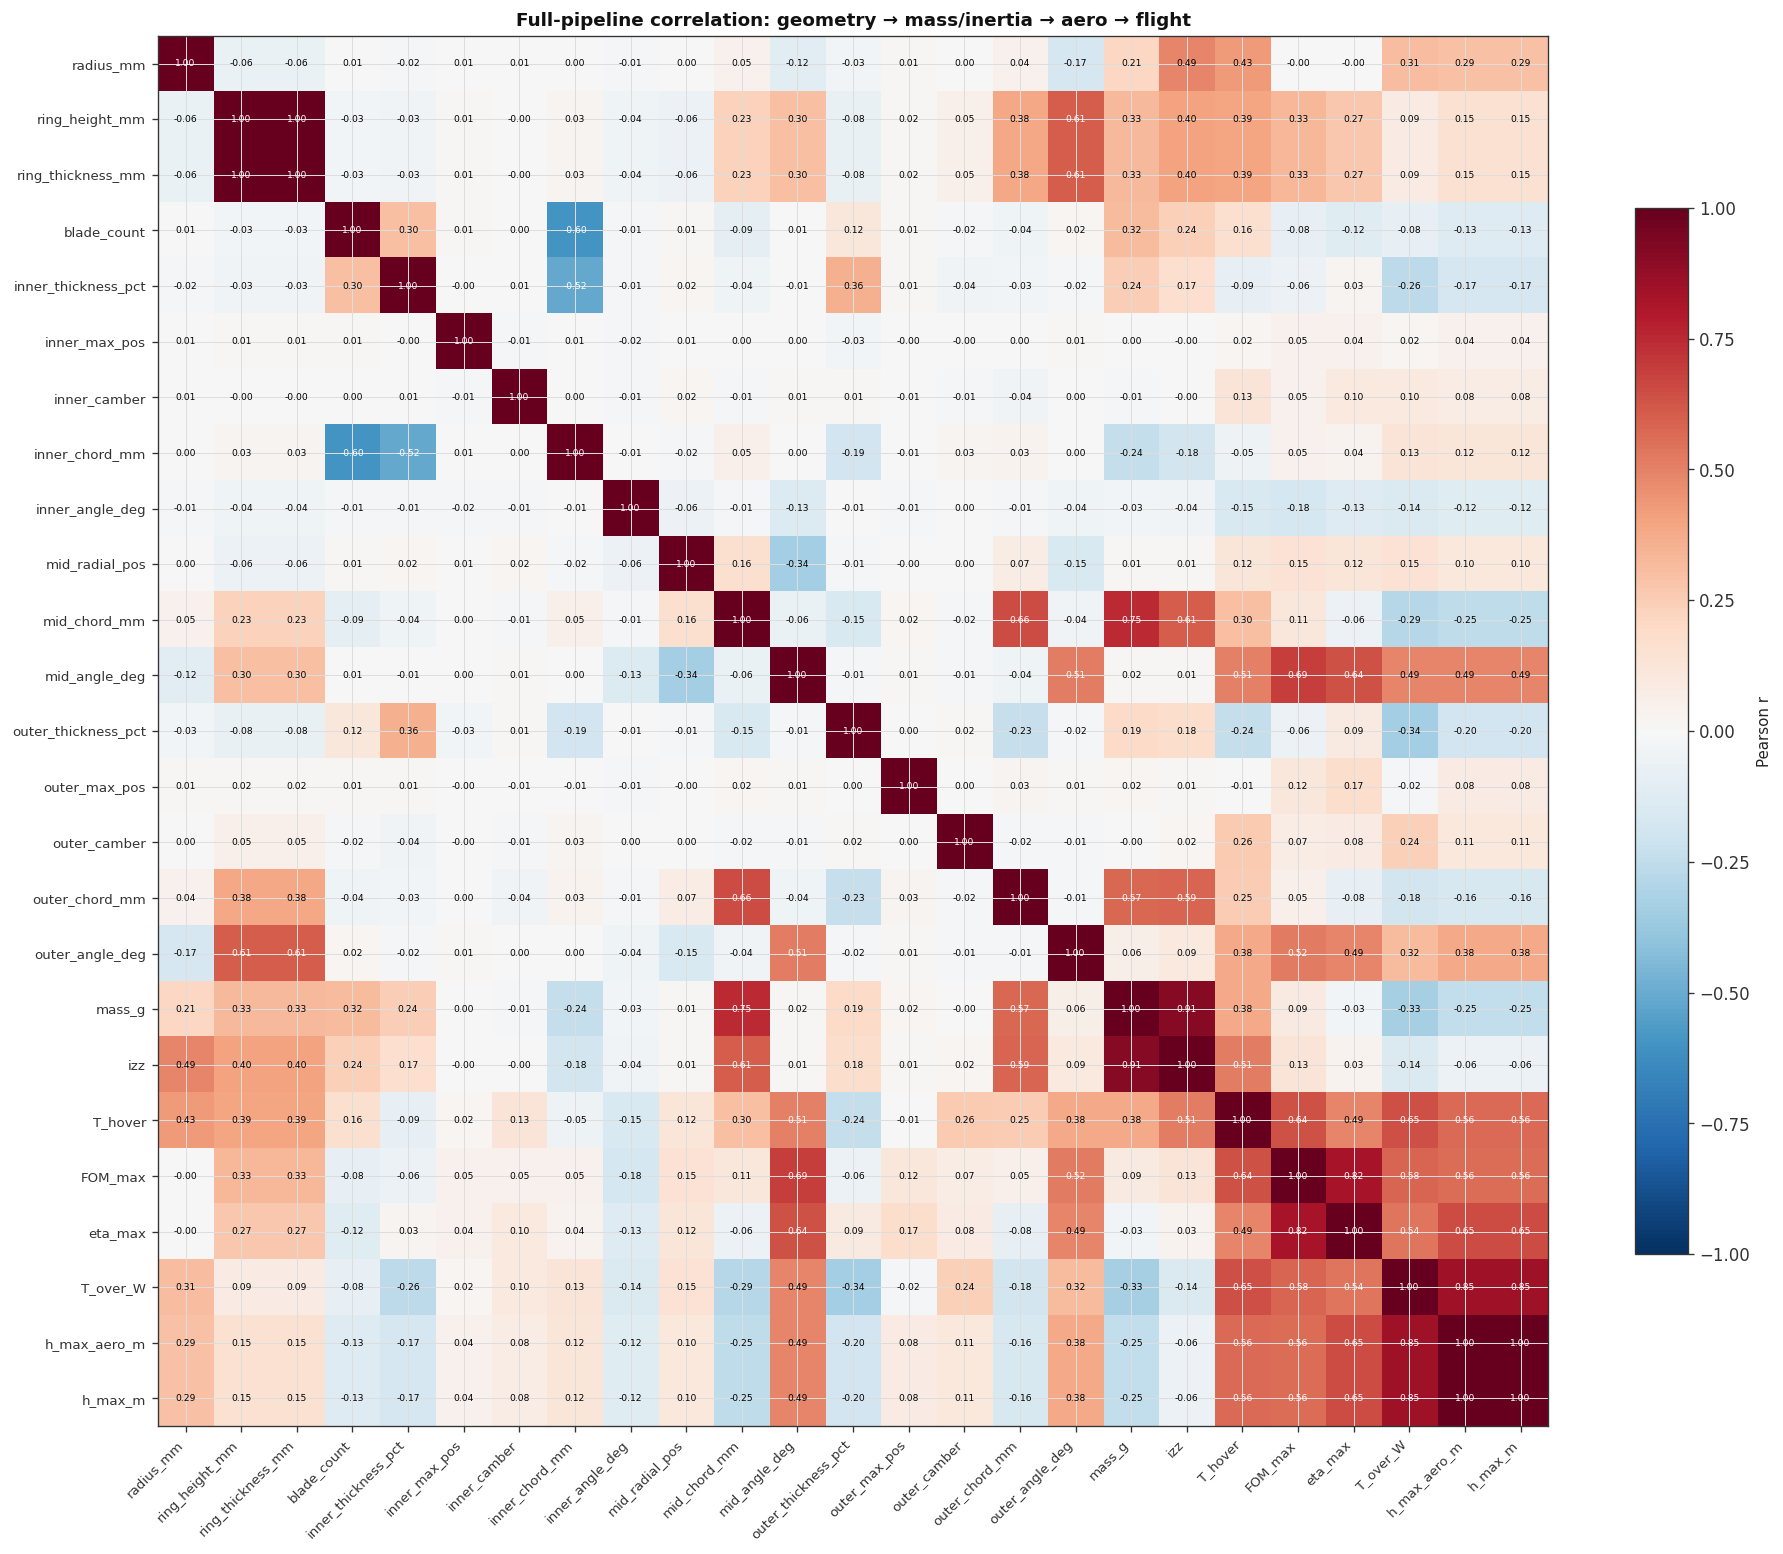

Correlation computed over 5000 configs and 25 variables.


In [36]:
geo_f = load('01_geometry.csv')
mi_f = load('03_mass_inertia.csv')
q_f = load('05_qprop_results.csv')
d_f = load('06b_flight_dynamics_release.csv')

GEO_PARAM_COLS = list(cfg.SLIDER_BOUNDS.keys())

frames = []
if geo_f is not None:
    frames.append(geo_f[['config_id'] + GEO_PARAM_COLS])
if mi_f is not None:
    if 'izz_regressed' in mi_f.columns:
        izz_source_col = 'izz_regressed'
    else:
        izz_source_col = 'izz'
    frames.append(mi_f[['config_id', 'mass_g', izz_source_col]].rename(columns={izz_source_col: 'izz'}))
if q_f is not None:
    keep = []
    for column in ['config_id', 'T_hover', 'FOM_max', 'eta_max']:
        if column in q_f.columns:
            keep.append(column)
    frames.append(q_f[keep])
if d_f is not None:
    keep = []
    for column in ['config_id', 'T_over_W', 'h_max_aero_m', 'h_max_m']:
        if column in d_f.columns:
            keep.append(column)
    frames.append(d_f[keep])

if len(frames) >= 2:
    merged = frames[0]
    for fr in frames[1:]:
        merged = merged.merge(fr, on='config_id', how='inner')
    num = merged.drop(columns=['config_id']).select_dtypes('number')
    corr = num.corr()
    fig, ax = plt.subplots(figsize=(16, 13))
    im = ax.imshow(corr.values, vmin=-1, vmax=1, cmap='RdBu_r')
    ax.set_xticks(range(len(corr)))
    ax.set_yticks(range(len(corr)))
    ax.set_xticklabels(corr.columns, rotation=45, ha='right', fontsize=8)
    ax.set_yticklabels(corr.columns, fontsize=8)
    for i in range(len(corr)):
        for j in range(len(corr)):
            v = corr.values[i, j]
            if abs(v) > 0.5:
                text_color = 'white'
            else:
                text_color = 'black'
            ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=5.5, color=text_color)
    plt.colorbar(im, ax=ax, shrink=0.75, label='Pearson r')
    ax.set_title('Full-pipeline correlation: geometry → mass/inertia → aero → flight', fontsize=11, fontweight='bold')
    plt.tight_layout()
    savefig('nb8/nb8_pipeline_correlation.png')
    print(f'Correlation computed over {len(merged)} configs and {len(corr)} variables.')

### 4.9 High-Resolution Results Figures

Regenerates every results-chapter figure as a standalone, high-resolution, single-concept 300-dpi PNG (each into the `plots/nb<N>/` folder of the stage it documents): the generation-stage balance and radial evolution, the aerodynamic coverage set, the QProp operating surfaces of the reference propeller, the representative-selection coverage, the illustrative low-Reynolds polar (Figure 2 of the thesis), the single simulated trajectory (Figure 8), the full validation figure set (mass, inertia, the four height scatters, height-vs-RPM, liftoff accuracy, kick evidence, confidence-vs-error, ranking-vs-RPM — these read the tables NB9 saves and are skipped with a notice until NB9 has run), and the spin-retention curve recomputed from the raw launcher traces (which also writes `csv/06b_release_retention_curve_recomputed.csv`).


In [37]:
fig_gen_param_distributions()
fig_gen_radial_evolution()
fig_aero_polar_tiers()
fig_aero_xfoil_convergence()
fig_aero_confidence_hist()
fig_aero_qprop_surfaces(885)
fig_selection_coverage()
fig_lowre_polar(config=145, station='s2', re_target=25000.0)
fig_release_trajectory(config=2257)


gen_param_distributions  (discrete + free parameter balance)
   saved: plots\nb1\gen_param_distributions.png
   n designs            : 5000
   blade_count counts   : {3: 1250, 4: 1250, 5: 1250, 6: 1250}
   radius range [mm]    : 60 - 80
   per-radius mean count: 238
   camber range         : 0.0000 - 9.0000
   max_pos range        : 2.0000 - 8.0000

gen_radial_evolution
   saved: plots\nb1\gen_radial_evolution.png
   designs lofted        : 5000
   chord  inner/mid/outer means [mm] : 6.64 / 19.25 / 14.62
   angle  inner/mid/outer means [deg]: 21.40 / 10.28 / 6.15
   thick  inner/mid(derived)/outer means [%] : 20.09 / 17.21 / 13.97
   chord & twist : cubic-spline loft through inner/mid/outer (all sampled)
   thickness/camber : NACA spline through inner/outer only (mid is DERIVED on that
                      curve, exactly as NB3 fit_naca_spline does — not independently sampled)

aero_polar_tiers  (tier distribution per station)
   saved: plots\nb4\aero_polar_tiers.png
   designs      

In [38]:
fig_val_mass_scatter()
fig_val_inertia_scatter()
figs_flight_scatters()
fig_flight_height_vs_rpm()
fig_flight_liftoff_accuracy()
fig_flight_kick_evidence()
fig_flight_confidence_vs_mae()
fig_flight_ranking_vs_rpm()
fig_flight_retention_curve()
print()
print('High-resolution results figures complete.')


val_mass_scatter  (predicted vs measured mass)
   saved: plots\nb9\val_mass_scatter.png
   n parts   : 100
   MAE       : 0.414 g  (3.45 %)
   bias      : +0.000 g
   Pearson r : 0.9863

val_inertia_scatter  (predicted vs measured spin-axis inertia)
   saved: plots\nb9\val_inertia_scatter.png
   n parts          : 100
   raw STL  MAE     : 6.66 %  bias +1.030e+00  r 0.9861
   corrected MAE    : 5.82 %  bias +1.104e-12  r 0.9861

flight_scatter_*  (sim vs measured peak height, 4 separate figures)
   saved: plots\nb9\flight_scatter_release_vs_mean.png
   nb9/flight_scatter_release_vs_mean: n=179  ρ=0.396  MAE=0.261  bias=+0.021
   saved: plots\nb9\flight_scatter_release_vs_median.png
   nb9/flight_scatter_release_vs_median: n=179  ρ=0.421  MAE=0.258  bias=+0.033
   saved: plots\nb9\flight_scatter_release_vs_reg.png
   nb9/flight_scatter_release_vs_reg: n=179  ρ=0.530  MAE=0.223  bias=+0.007
   saved: plots\nb9\flight_scatter_aero_vs_mean.png
   nb9/flight_scatter_aero_vs_mean: n=84  ρ=0